In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW
from wrf_io import rotor_average
from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [3]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [4]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * rotor.R + 378

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn201005',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v201005',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn201005',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v201005',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn201005',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v201005',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn201005',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v201005',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn201005',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v201005',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn201005',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v201005',
r's030151_v402010'
]

In [8]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/'+casenames[count]+'_lite.npz')))

In [9]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [10]:
wrf_ind   = np.zeros(len(coords), dtype=float)
wrf_cot   = np.zeros(len(coords), dtype=float)

wrf_tsr   = np.zeros(len(coords), dtype=float)

wrf_cax   = np.zeros(len(coords), dtype=float)
wrf_vax   = np.zeros(len(coords), dtype=float)
wrf_vtn   = np.zeros(len(coords), dtype=float)

wrf_rel   = np.zeros(len(coords), dtype=float)

wrf_pow   = np.zeros(len(coords), dtype=float)
wrf_thr   = np.zeros(len(coords), dtype=float)

U_loc     = np.zeros((nElements, nSections, len(coords)))
dir_loc   = np.zeros((nElements, nSections, len(coords)))

shapiro   = np.zeros(len(coords), dtype=float)

Uhub     = np.zeros(len(coords), dtype=float)

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles_bem[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Background wind speed
    U = np.sqrt(u_inf**2 + v_inf**2)

    # Background wind direction
    wdir = np.atan2(v_inf,u_inf)

    # Radial coordinates
    r = wrfles_bem[count]['rOverR'] * rotor.R
    r =  (np.ones_like(wdir) * r).T
    mu = wrfles_bem[count]['rOverR']

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, nSections)

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(378)**2 + v_func(378)**2)

    # Compute induction
    a = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / U_hub
    a_bar = 1/(2 * np.pi) * np.trapezoid(2 * np.trapezoid(a.T * mu, mu), theta, axis=-1)

    # Compute inflow angle, lift, and drag coefficients
    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    # Radial chord lengths
    chord = [4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734]
    chord =  (np.ones_like(Cd.T) * chord).T

    # Local solidity
    sigma = (3 * chord) / (2 * np.pi * r)

    # Tip speed ratio
    tsr = np.mean(wrfles_bem[count]['omega']*R*2*np.pi/(U_hub*60), axis=0) 

    aprime=0

    local_yaw = wdir.T

    Vax = (
        U.T/U_hub
        * (1 - a_bar.T)
        * np.cos(local_yaw * np.cos(theta))
        * np.cos(local_yaw * np.sin(theta))
    )
    Vtan = (
        (1 + aprime) * tsr * r/R
        - U.T/U_hub * (1 - a_bar.T)
        * np.cos(local_yaw * np.sin(theta))
        * np.sin(local_yaw * np.cos(theta))
    )

    W = np.sqrt(Vax**2 + Vtan**2)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    U_loc[:,:,count]   = U.T/U_hub
    dir_loc[:,:,count] = wdir.T
    Uhub[count]        = U_hub
    wrf_rel[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(W, theta, axis=-1) * mu, mu)
    wrf_vax[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Vax, theta, axis=-1) * mu, mu)
    wrf_vtn[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Vtan, theta, axis=-1) * mu, mu)
    wrf_cax[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(Cax, theta, axis=-1) * mu, mu)
    wrf_cot[count]     = 2 * np.trapezoid(1/(2 * np.pi) * np.trapezoid(ct, theta, axis=-1) * mu, mu)
    wrf_ind[count]     = a_bar
    wrf_thr[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
    wrf_pow[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
    shapiro[count]     = wrfles_bem[count]['shapiroM'][1]
    wrf_tsr[count]     = tsr


/tmp/ipykernel_2621881/2660156402.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_thr[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
/tmp/ipykernel_2621881/2660156402.py:105: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_pow[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
/tmp/ipykernel_2621881/2660156402.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shapiro[count]     = wrfles_bem[count]['shapiroM'][1]
/tmp/ipykernel_

In [ ]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    return a * CT**3 + b * CT**2 + c * CT

In [15]:
veer  = np.array([-80,-40,-20,-10,0,10,20,40,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

indices_80 = [i for i, (s, v) in enumerate(training) if abs(v) == 80]
indices_40 = [i for i, (s, v) in enumerate(training) if abs(v) == 40]
indices_20 = [i for i, (s, v) in enumerate(training) if abs(v) == 20]
indices_10 = [i for i, (s, v) in enumerate(training) if abs(v) == 10]
indices_00 = [i for i, (s, v) in enumerate(training) if abs(v) == 0]


In [40]:
# V80

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.01,5)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_80])
ct_mom = np.append(ct_mom, wrf_cot[indices_80])

# a_mom = wrf_ind[indices_80]
# ct_mom = wrf_cot[indices_80]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v80, b_fit_v80, c_fit_v80 = params
# print(f"Fitted parameters: a = {a_fit_v80:.3f}, b = {b_fit_v80:.3f}, c = {c_fit_v80:.3f},")
print(f"Fitted parameters: {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

np.save("./rotor_coefficients/shapiro/v80_10MW_rotor_coefficients.npy", [a_fit_v80,b_fit_v80,c_fit_v80])

# Generate fitted values
x_fit_v80 = np.linspace(0, 2, 300)
y_fit_v80 = madsen_func(x_fit_v80, a_fit_v80, b_fit_v80, c_fit_v80)

Fitted parameters: 1.116, -0.704, 0.273


In [41]:
# V40

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.01,5)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_40])
ct_mom = np.append(ct_mom, wrf_cot[indices_40])

# a_mom = wrf_ind[indices_40]
# ct_mom = wrf_cot[indices_40]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v40, b_fit_v40, c_fit_v40 = params
print(f"Fitted parameters: a = {a_fit_v40:.3f}, b = {b_fit_v40:.3f}, c = {c_fit_v40:.3f},")
print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("./rotor_coefficients/shapiro/v40_10MW_rotor_coefficients.npy", [a_fit_v40,b_fit_v40,c_fit_v40])

# Generate fitted values
x_fit_v40 = np.linspace(0, 2, 300)
y_fit_v40 = madsen_func(x_fit_v40, a_fit_v40, b_fit_v40, c_fit_v40)

Fitted parameters: a = 0.828, b = -0.526, c = 0.268,
Fitted parameters: 0.828, -0.526, 0.268


In [42]:
# V20

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.01,5)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_20])
ct_mom = np.append(ct_mom, wrf_cot[indices_20])

# a_mom = wrf_ind[indices_20]
# ct_mom = wrf_cot[indices_20]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v20, b_fit_v20, c_fit_v20 = params
print(f"Fitted parameters: a = {a_fit_v20:.3f}, b = {b_fit_v20:.3f}, c = {c_fit_v20:.3f},")
print(f"Fitted parameters: {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")

np.save("./rotor_coefficients/shapiro/v20_10MW_rotor_coefficients.npy", [a_fit_v20,b_fit_v20,c_fit_v20])

# Generate fitted values
x_fit_v20 = np.linspace(0, 2, 300)
y_fit_v20 = madsen_func(x_fit_v20, a_fit_v20, b_fit_v20, c_fit_v20)

Fitted parameters: a = -0.483, b = 0.507, c = 0.236,
Fitted parameters: -0.483, 0.507, 0.236


In [43]:
# V10

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.01,5)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_10])
ct_mom = np.append(ct_mom, wrf_cot[indices_10])

# a_mom = wrf_ind[indices_10]
# ct_mom = wrf_cot[indices_10]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v10, b_fit_v10, c_fit_v10 = params
print(f"Fitted parameters: a = {a_fit_v10:.3f}, b = {b_fit_v10:.3f}, c = {c_fit_v10:.3f},")
print(f"Fitted parameters: {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")

np.save("./rotor_coefficients/shapiro/v10_10MW_rotor_coefficients.npy", [a_fit_v10,b_fit_v10,c_fit_v10])

# Generate fitted values
x_fit_v10 = np.linspace(0, 2, 300)
y_fit_v10 = madsen_func(x_fit_v10, a_fit_v10, b_fit_v10, c_fit_v10)

Fitted parameters: a = -1.814, b = 1.576, c = 0.202,
Fitted parameters: -1.814, 1.576, 0.202


In [44]:
# V00

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.01,5)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_00])
ct_mom = np.append(ct_mom, wrf_cot[indices_00])

# a_mom = wrf_ind[indices_00]
# ct_mom = wrf_cot[indices_00]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v00, b_fit_v00, c_fit_v00 = params
print(f"Fitted parameters: a = {a_fit_v00:.3f}, b = {b_fit_v00:.3f}, c = {c_fit_v00:.3f},")
print(f"Fitted parameters: {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

np.save("./rotor_coefficients/shapiro/v00_10MW_rotor_coefficients.npy", [a_fit_v00,b_fit_v00,c_fit_v00])

# Generate fitted values
x_fit_v00 = np.linspace(0, 2, 300)
y_fit_v00 = madsen_func(x_fit_v00, a_fit_v00, b_fit_v00, c_fit_v00)

Fitted parameters: a = -2.909, b = 2.459, c = 0.175,
Fitted parameters: -2.909, 2.459, 0.175


In [45]:
print("if int(abs(self.veer)) == 0:")
print(f"    a,b,c = {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")
print("elif int(abs(self.veer)) == 1:")
print(f"    a,b,c = {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")
print("elif int(abs(self.veer)) == 2:")
print(f"    a,b,c = {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")
print("elif int(abs(self.veer)) == 4:")
print(f"    a,b,c = {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")
print("elif int(abs(self.veer)) == 8:")
print(f"    a,b,c = {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

if int(abs(self.veer)) == 0:
    a,b,c = -2.909, 2.459, 0.175
elif int(abs(self.veer)) == 1:
    a,b,c = -1.814, 1.576, 0.202
elif int(abs(self.veer)) == 2:
    a,b,c = -0.483, 0.507, 0.236
elif int(abs(self.veer)) == 4:
    a,b,c = 0.828, -0.526, 0.268
elif int(abs(self.veer)) == 8:
    a,b,c = 1.116, -0.704, 0.273


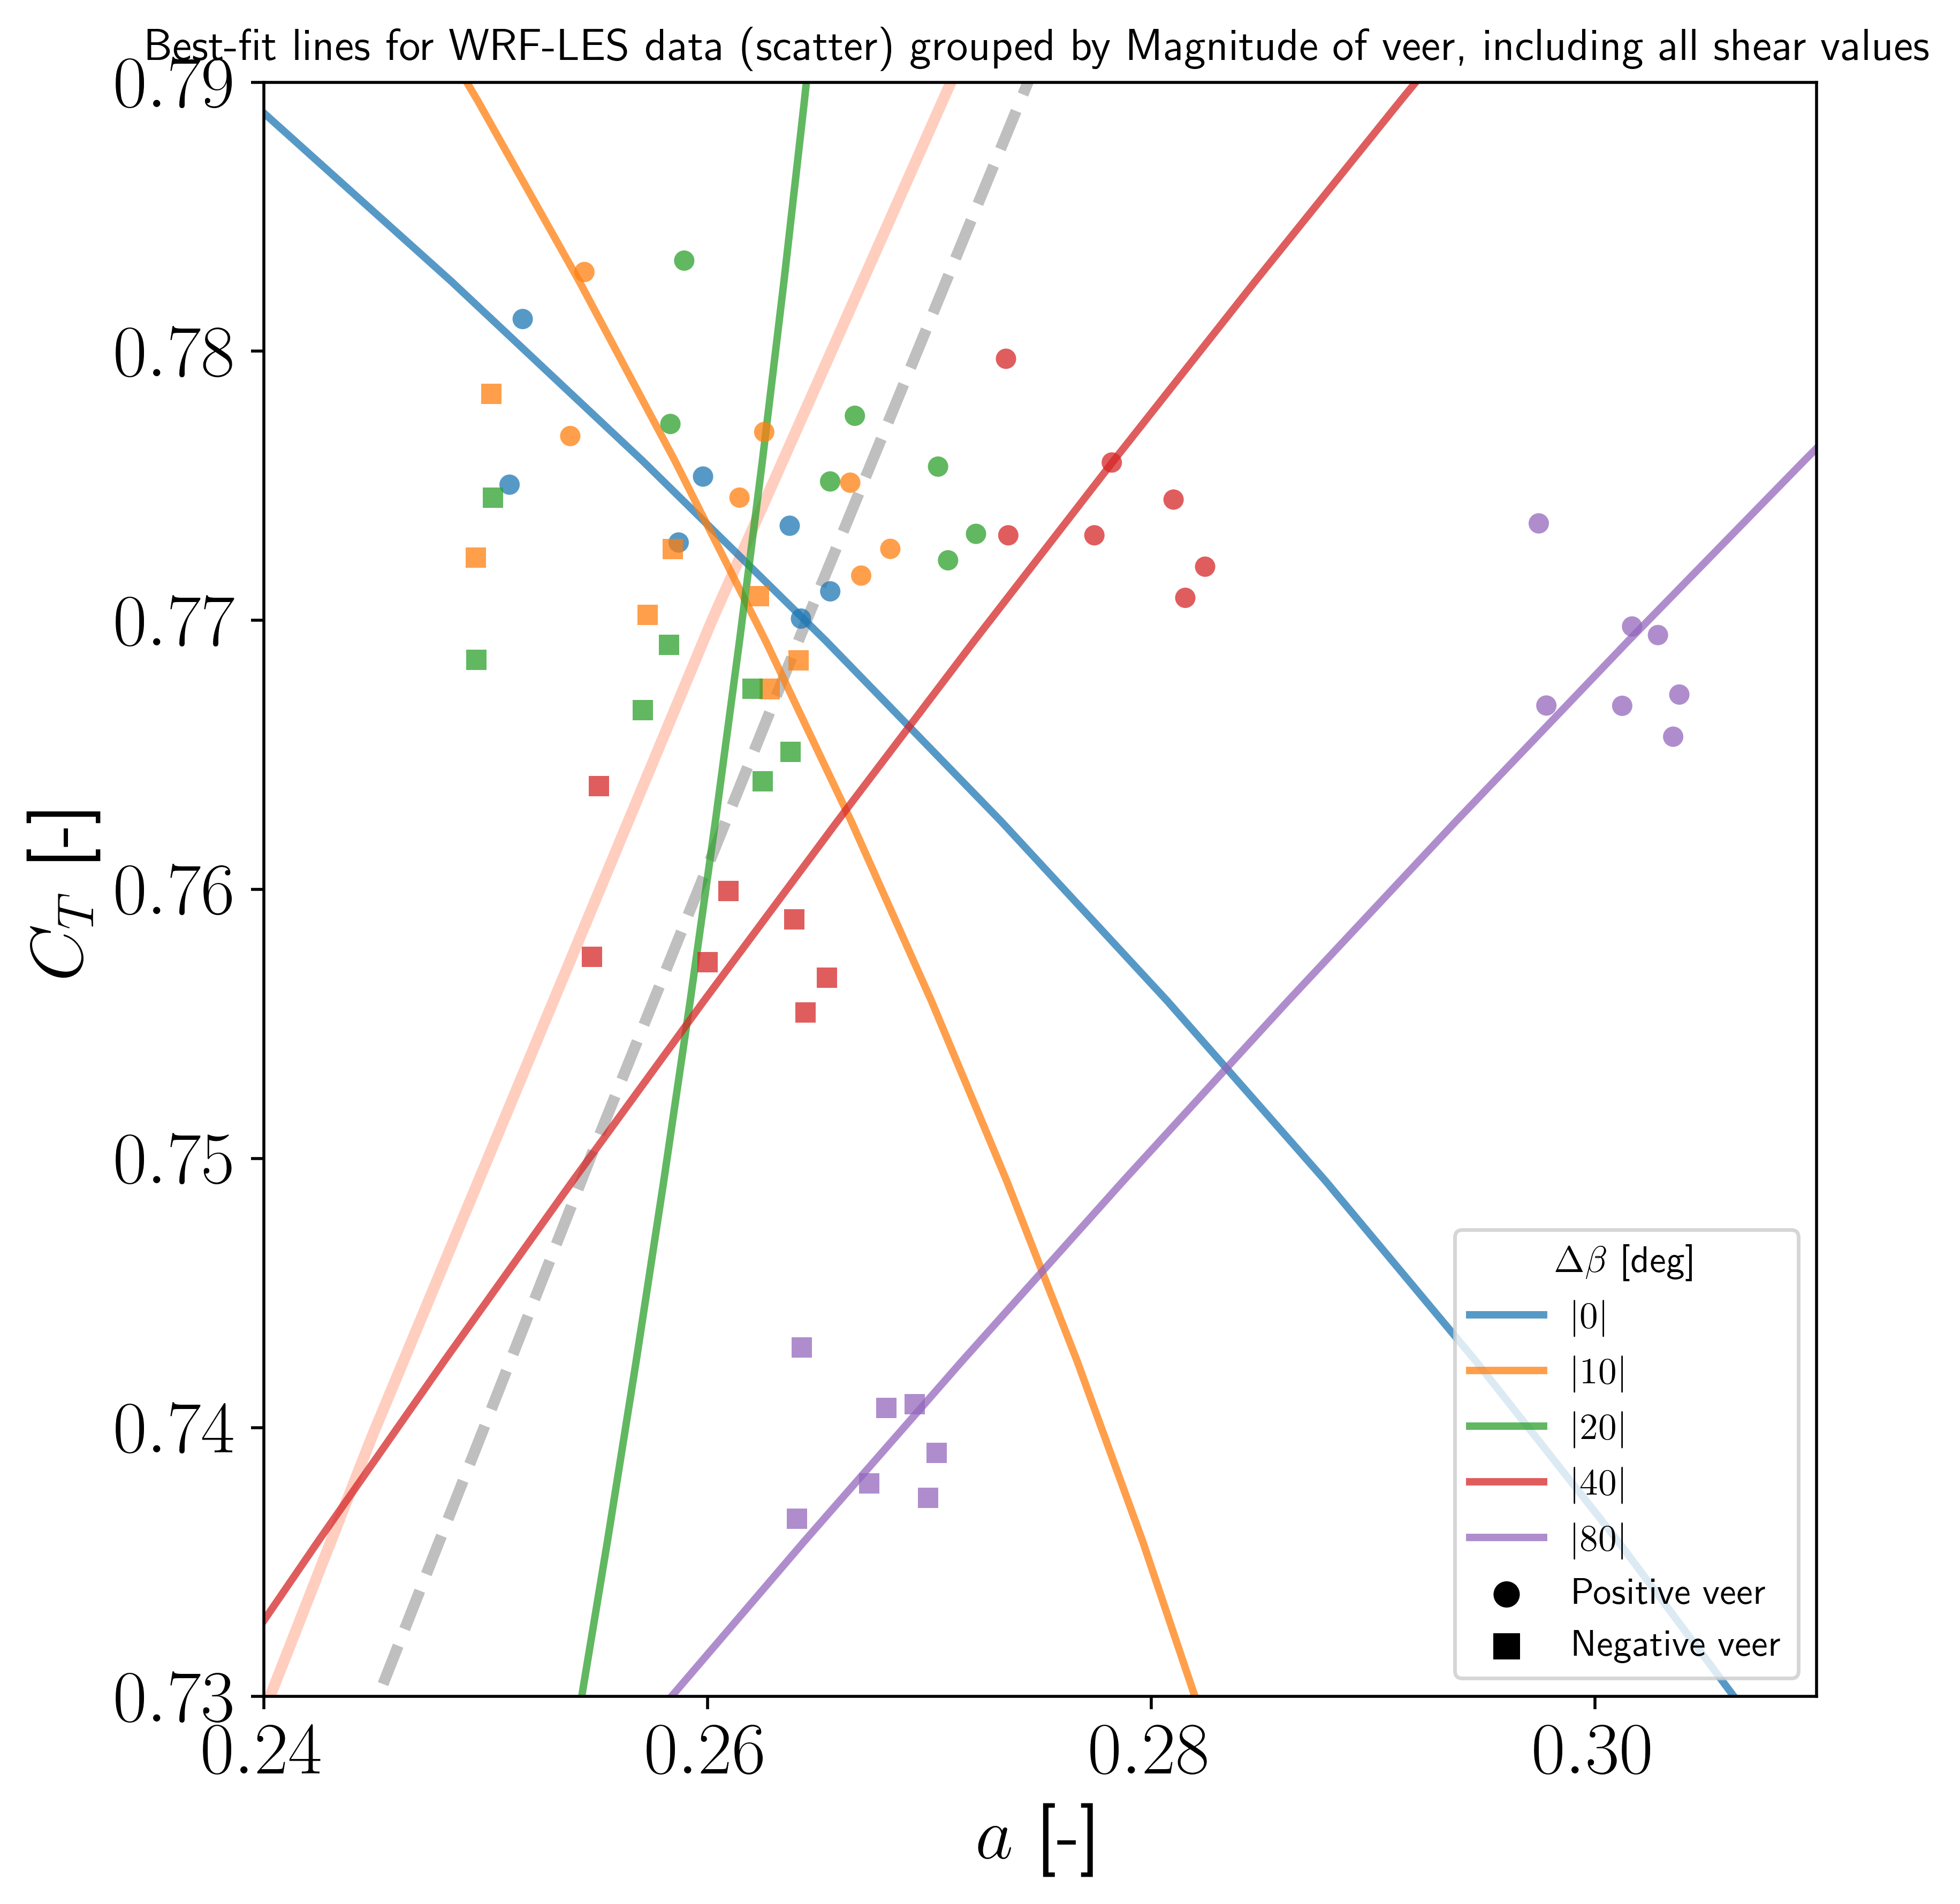

In [ ]:
colors = sns.color_palette("tab10",5)

m_size = 30
line_alpha = 0.75

indices_p80 = [i for i, (s, v) in enumerate(training) if v == 80]
indices_n80 = [i for i, (s, v) in enumerate(training) if v == -80]

indices_p40 = [i for i, (s, v) in enumerate(training) if v == 40]
indices_n40 = [i for i, (s, v) in enumerate(training) if v == -40]

indices_p20 = [i for i, (s, v) in enumerate(training) if v == 20]
indices_n20 = [i for i, (s, v) in enumerate(training) if v == -20]

indices_p10 = [i for i, (s, v) in enumerate(training) if v == 10]
indices_n10 = [i for i, (s, v) in enumerate(training) if v == -10]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$|0|$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$|10|$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$|20|$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$|40|$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$|80|$')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=m_size, edgecolor='none',color=colors[0],zorder=3,alpha=line_alpha)

for i in range(len(indices_p10)):
    mesh = ax.scatter(wrf_ind[indices_p10[i]], wrf_cot[indices_p10[i]], s=m_size, edgecolor='none',color=colors[1],zorder=3,marker='o',alpha=line_alpha)
for i in range(len(indices_n10)):
    mesh = ax.scatter(wrf_ind[indices_n10[i]], wrf_cot[indices_n10[i]], s=m_size, edgecolor='none',color=colors[1],zorder=3,marker='s',alpha=line_alpha)

for i in range(len(indices_p20)):
    mesh = ax.scatter(wrf_ind[indices_p20[i]], wrf_cot[indices_p20[i]], s=m_size, edgecolor='none',color=colors[2],zorder=3,marker='o',alpha=line_alpha)
for i in range(len(indices_n20)):
    mesh = ax.scatter(wrf_ind[indices_n20[i]], wrf_cot[indices_n20[i]], s=m_size, edgecolor='none',color=colors[2],zorder=3,marker='s',alpha=line_alpha)

for i in range(len(indices_p40)):
    mesh = ax.scatter(wrf_ind[indices_p40[i]], wrf_cot[indices_p40[i]], s=m_size, edgecolor='none',color=colors[3],zorder=3,marker='o',alpha=line_alpha)
for i in range(len(indices_n40)):
    mesh = ax.scatter(wrf_ind[indices_n40[i]], wrf_cot[indices_n40[i]], s=m_size, edgecolor='none',color=colors[3],zorder=3,marker='s',alpha=line_alpha)

for i in range(len(indices_p80)):
    mesh = ax.scatter(wrf_ind[indices_p80[i]], wrf_cot[indices_p80[i]], s=m_size, edgecolor='none',color=colors[4],zorder=3,marker='o',alpha=line_alpha)
for i in range(len(indices_n80)):
    mesh = ax.scatter(wrf_ind[indices_n80[i]], wrf_cot[indices_n80[i]], s=m_size, edgecolor='none',color=colors[4],zorder=3,marker='s',alpha=line_alpha)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',marker='o',label='Positive veer')
mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',marker='s',label='Negative veer')

ax.legend(title='$\Delta \\beta$ [deg]',loc='lower right')

ax.set_title('Best-fit lines for WRF-LES data (scatter) grouped by magnitude of veer, including all shear values')

# fig.text(0.55,0.40, f'Coefficients with Shapiro correction:', ha='left', fontsize=12,rotation=0,color='k')
# fig.text(0.55,0.35, f'$a = {a_fit_v00:0.3f}C_T^3 + {b_fit_v00:0.3f}C_T^2 + {c_fit_v00:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[0])
# fig.text(0.55,0.30, f'$a = {a_fit_v10:0.3f}C_T^3 + {b_fit_v10:0.3f}C_T^2 + {c_fit_v10:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[1])
# fig.text(0.55,0.25, f'$a = {a_fit_v20:0.3f}C_T^3 + {b_fit_v20:0.3f}C_T^2 + {c_fit_v20:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[2])
# fig.text(0.55,0.20, f'$a = {a_fit_v40:0.3f}C_T^3 + {b_fit_v40:0.3f}C_T^2 + {c_fit_v40:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[3])
# fig.text(0.55,0.15, f'$a = {a_fit_v80:0.3f}C_T^3 + {b_fit_v80:0.3f}C_T^2 + {c_fit_v80:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[4])

ax.set_xlim([0.24,0.31])
ax.set_ylim([0.73,0.79])

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)

plt.show()

In [26]:
ind_ubar = [31,32,33,34,35]

wrf_pow_ss = np.zeros_like(casenames, dtype='float')
wrf_thr_ss = np.zeros_like(casenames, dtype='float')
wrf_cot_ss = np.zeros_like(casenames, dtype='float')
wrf_ind_ss = np.zeros_like(casenames, dtype='float')


for i in range(len(ind_ubar)):
    wrf_pow_ss[i] = wrf_pow[ind_ubar[i]]
    wrf_thr_ss[i] = wrf_thr[ind_ubar[i]]
    wrf_cot_ss[i] = wrf_cot[ind_ubar[i]]
    wrf_ind_ss[i] = wrf_ind[ind_ubar[i]]

In [27]:
wrf_power_dev     = postproc.per_error(wrf_pow_ss, wrf_pow_ss[0])
wrf_thrust_dev    = postproc.per_error(wrf_thr_ss, wrf_thr_ss[0])
wrf_induction_dev = postproc.per_error(wrf_ind_ss, wrf_ind_ss[0])

In [23]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors

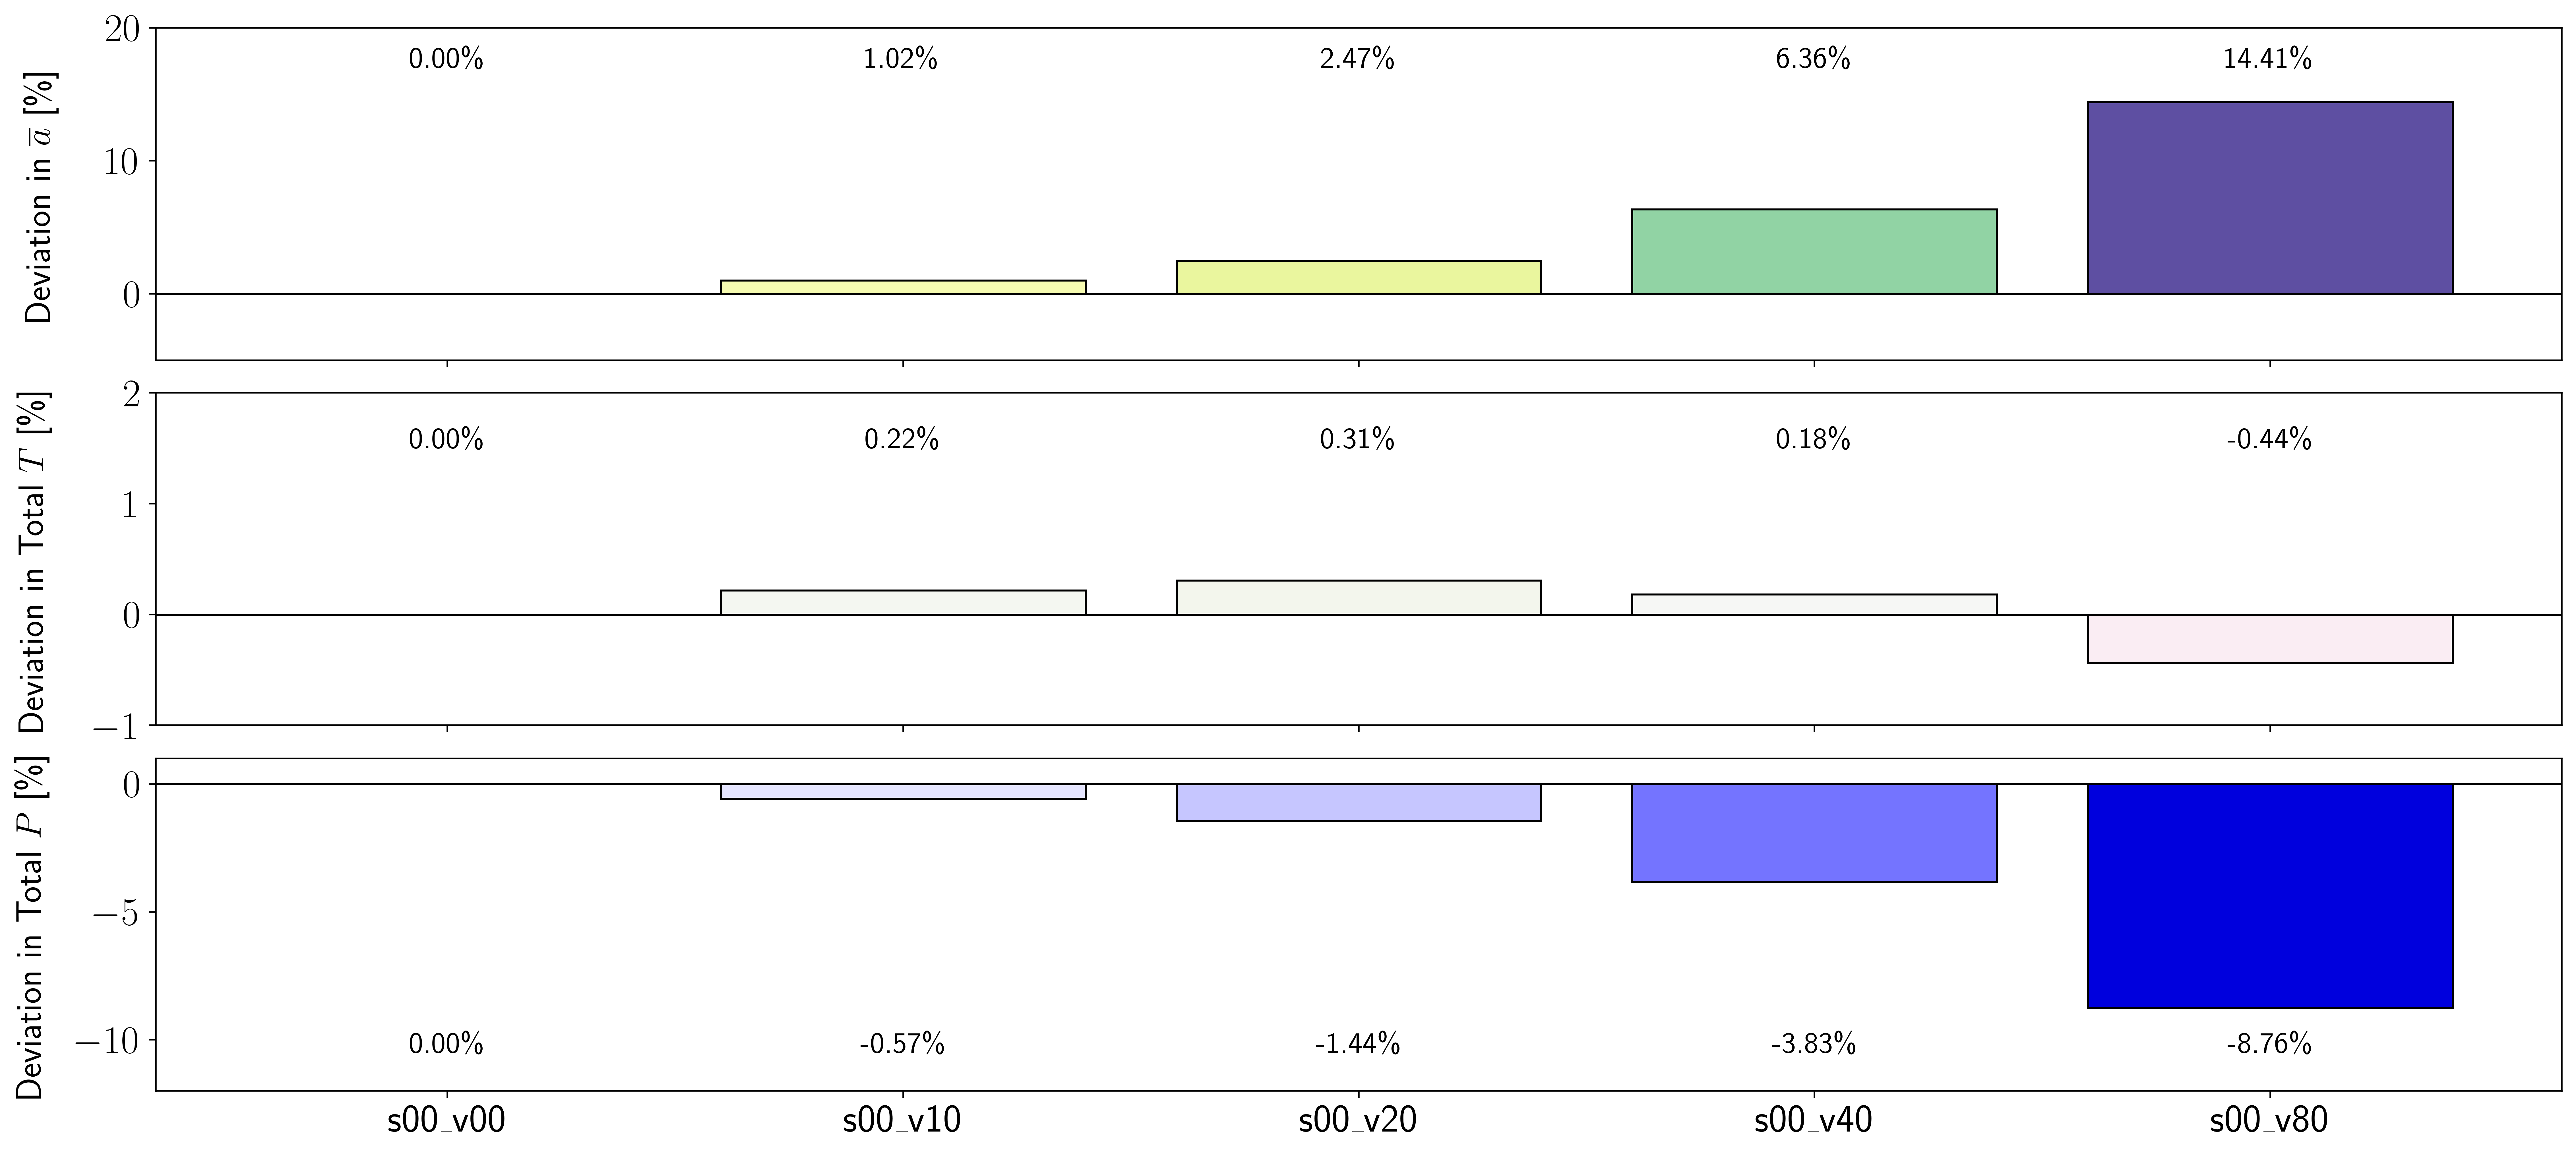

In [24]:
# casenames = [r's00_vn80', r's00_vn40', r's00_vn20', r's00_vn10', r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']


width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], wrf_induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[0].text(ind[count], 17, f'{wrf_induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-5,20])

    # thrust
    ax[1].bar(ind[count], wrf_thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=21)
    ax[1].text(ind[count], 1.5, f'{wrf_thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-1,2])

    # power
    ax[2].bar(ind[count], wrf_power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=13)
    ax[2].text(ind[count], -10.5, f'{wrf_power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-12,1])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [25]:
casenames = [
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010'
]

In [22]:
from MITRotor import BEM, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, Madsen_Rotor_Momentum

In [23]:
rotor = IEA10MW()
veers = [0,1,2,4,8]

casenames = [
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010']

mit_ind = np.zeros_like(casenames, dtype='float')
mit_cot = np.zeros_like(casenames, dtype='float')
mit_thr = np.zeros_like(casenames, dtype='float')
mit_cop = np.zeros_like(casenames, dtype='float')
mit_pow = np.zeros_like(casenames, dtype='float')
iters   = np.zeros_like(casenames, dtype='float')

mit_w   = np.zeros_like(casenames, dtype='float')
mit_cax = np.zeros_like(casenames, dtype='float')
mit_vax = np.zeros_like(casenames, dtype='float')
mit_vtn = np.zeros_like(casenames, dtype='float')

ind_ubar = [31,32,33,34,35]

for count in range(len(casenames)):

    bem = BEM(rotor=rotor, aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    tsr = wrf_tsr[count] * rotor.R / R

    t = np.linspace(0,2*np.pi,nSections)
    r = wrfles_bem[0]['rOverR']

    interpU = RegularGridInterpolator(
    (r, t), U_loc[:,:,ind_ubar[count]], bounds_error=False, fill_value=None
    )

    interpW = RegularGridInterpolator(
    (r, t), dir_loc[:,:,ind_ubar[count]], bounds_error=False, fill_value=None
    )

    t_new = np.linspace(0,2*np.pi,20)
    r_new = np.linspace(0,1,10)

    R_new, T_new = np.meshgrid(r_new, t_new, indexing='ij')

    points = np.column_stack((R_new.ravel(), T_new.ravel()))  # shape (Nr*Nt, 2)
    U_interp_flat = interpU(points)
    W_interp_flat = interpW(points)
    U_interp = U_interp_flat.reshape(R_new.shape)
    W_interp = W_interp_flat.reshape(R_new.shape)

    r_dim = r_new * rotor.R

    sol = bem(0, tsr-0.328, 0, U = U_interp, wdir=W_interp,veer=veers[count])
    # sol = bem(0, tsr, 0, U = U_interp, wdir=W_interp,veer=veers[count])

    dr = r_dim[1] - r_dim[0]

    rho = 1.225


    Nr = 10  # number of radial points
    Ntheta = 20  # number of azimuthal points
    # r = sol.geom.mu_mesh[:,0] * rotor.R
    r =np.linspace(0,1,10) * rotor.R
    theta = sol.geom.theta_mesh[0,:]
    R_grid, Theta_grid = np.meshgrid(r, theta, indexing='ij')  # shape (Nr, Ntheta)

    # U_inf and CT are 2D arrays of shape (Nr, Ntheta)
    # Example (replace with your actual data):
    # U_inf = your_2D_array_for_local_velocity
    # CT = your_2D_array_for_thrust_coefficient

    # Compute local area element: dA = r * dr * dθ
    dr = rotor.R / (Nr - 1)
    dtheta = 2 * np.pi / Ntheta
    dA = R_grid * dr * dtheta  # shape (Nr, Ntheta)

    # Compute total thrust
    integrand = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**2 * sol.Ct('sector') * dA
    T_total = np.sum(integrand)

    local_power = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**3 * sol.Cp('sector') * dA

    P_total = np.sum(local_power)

    # from scipy.integrate import simpson

    # integrand_T = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**2 * sol.Ct('sector') * R_grid
    # integrand_P = 0.5 * rho * (sol.U('sector')*np.cos(sol.wdir('sector'))*7)**3 * sol.Cp('sector') * R_grid

    # # Integrate over theta, then over r
    # T_total = simpson(simpson(integrand_T, x=theta, axis=1), x=r)
    # P_total = simpson(simpson(integrand_P, x=theta, axis=1), x=r)

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total/1e3
    mit_pow[count] = P_total/1e6
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cx()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([3., 4., 4., 5., 7.])

In [24]:
mit_power_dev     = postproc.per_error(mit_cop, mit_cop[0])
mit_thrust_dev    = postproc.per_error(mit_cot, mit_cot[0])
mit_induction_dev = postproc.per_error(mit_ind, mit_ind[0])

In [126]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in mit_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in mit_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in mit_induction_dev]  # Map power to discrete colors

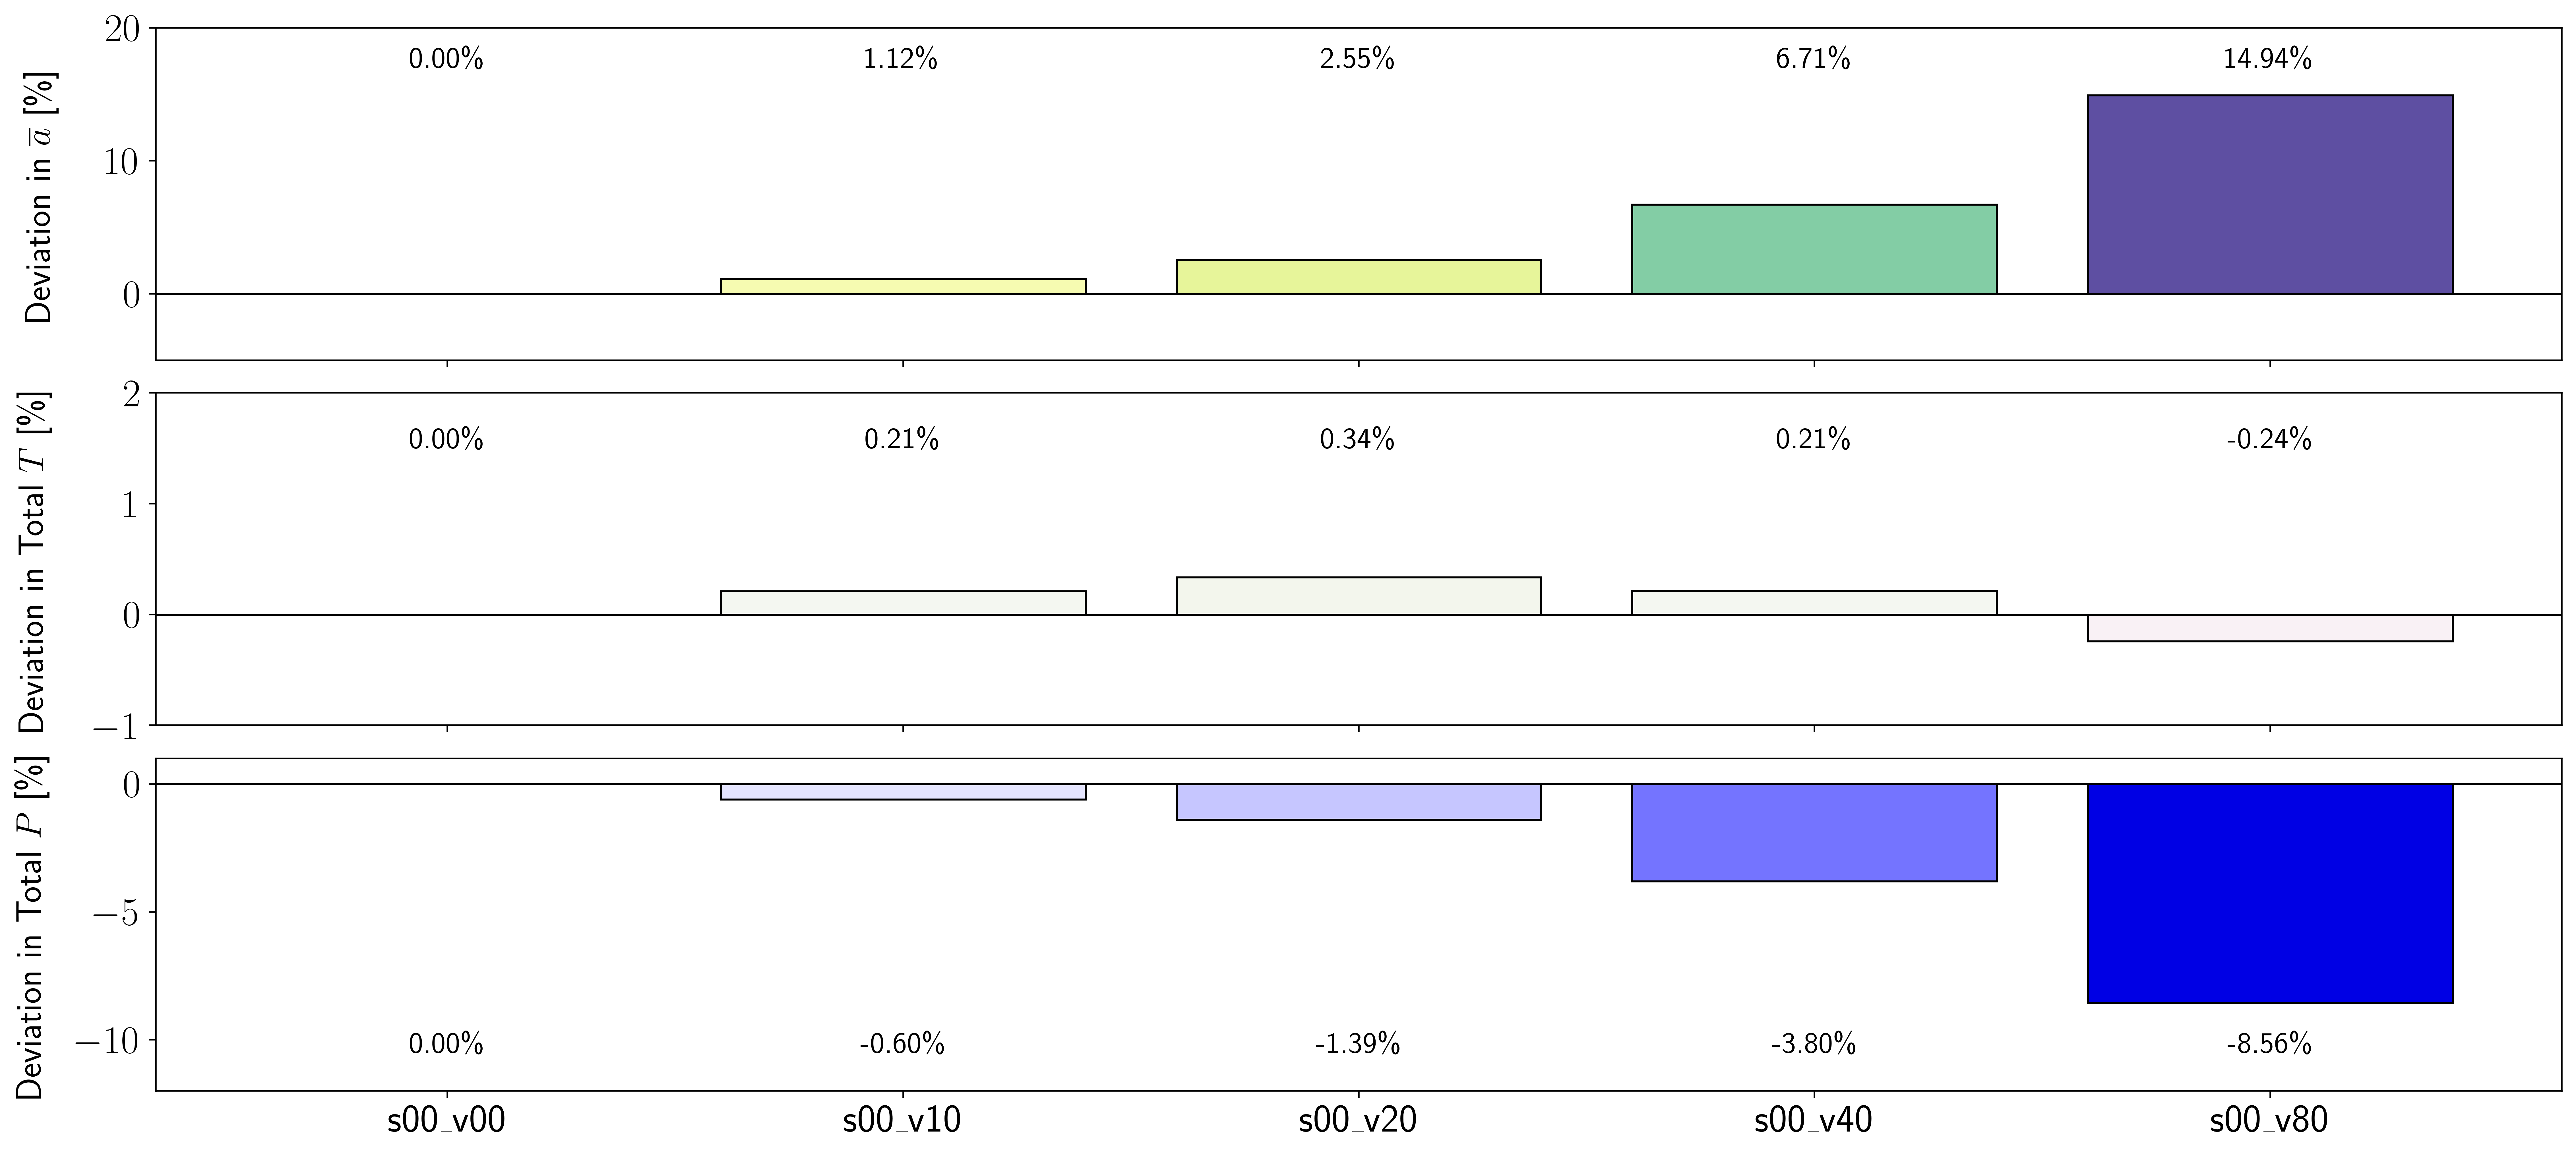

In [ ]:
# casenames = [r's00_vn80', r's00_vn40', r's00_vn20', r's00_vn10', r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']



width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], mit_induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=24)
    ax[0].text(ind[count], 17, f'{mit_induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-5,20])

    # thrust
    ax[1].bar(ind[count], mit_thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=21)
    ax[1].text(ind[count], 1.5, f'{mit_thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-1,2])

    # power
    ax[2].bar(ind[count], mit_power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=13)
    ax[2].text(ind[count], -10.5, f'{mit_power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-12,1])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

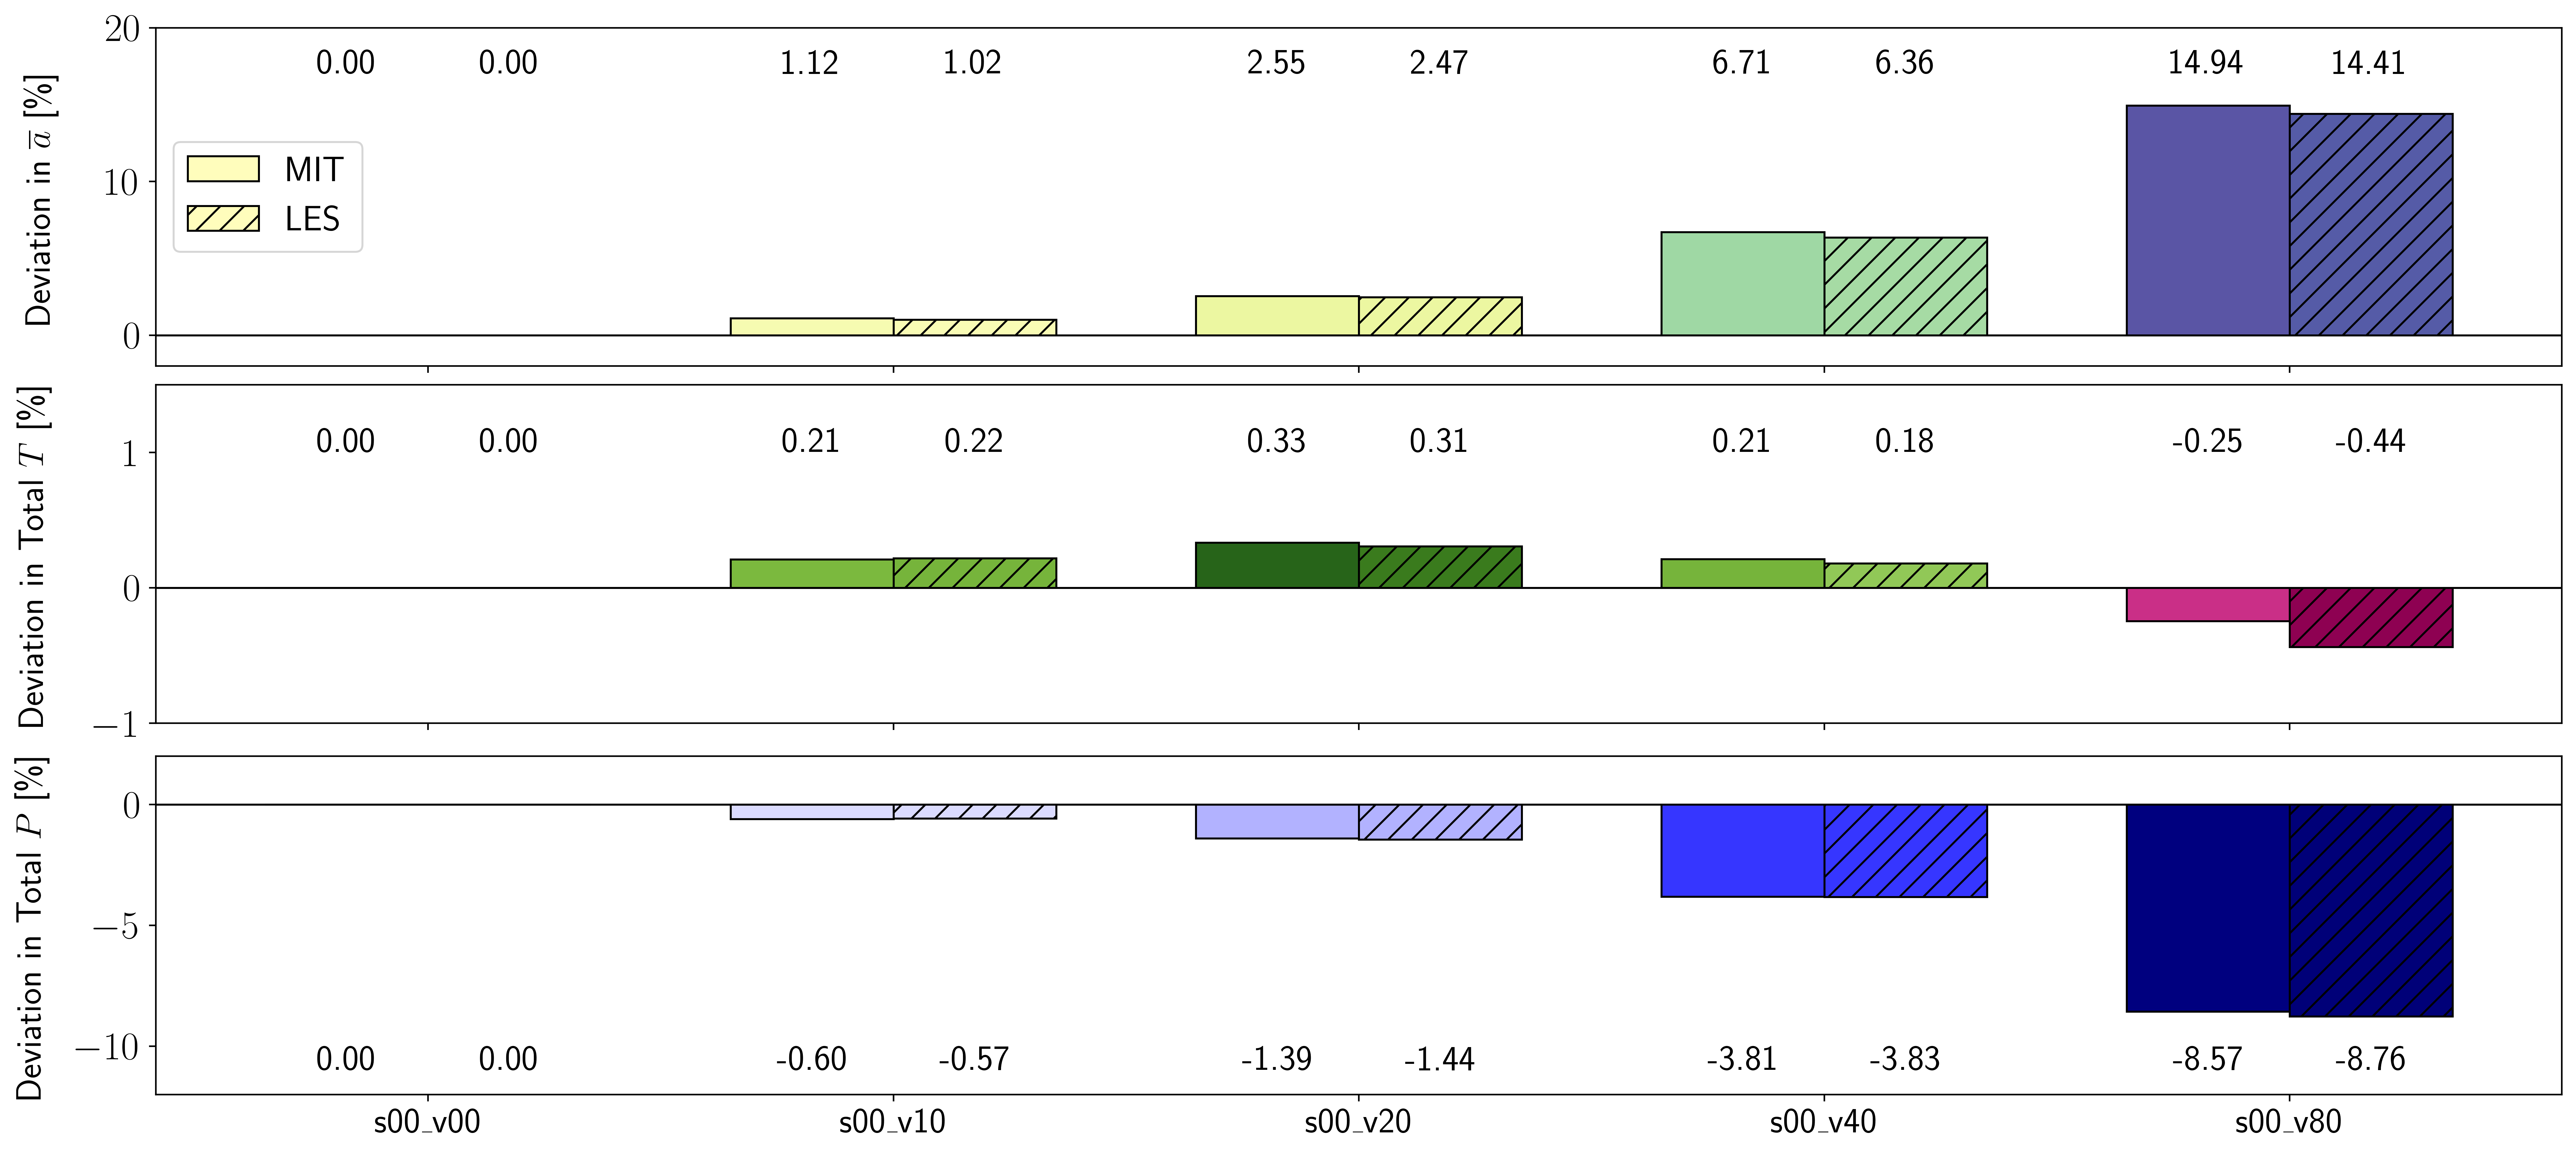

In [29]:
# Relative
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']

width = 0.35
alpha = 1.0
fontsize = 18

n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-10, vmax=10)  # Normalize power to [0, 1]
wrf_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors
mit_pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in mit_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-1/3, vmax=1/3)  # Normalize power to [0, 1]
wrf_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors
mit_thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in mit_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
wrf_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors
mit_ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in mit_induction_dev]  # Map power to discrete colors

ind = np.arange(len(casenames))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(casenames)):
    # --- Induction
    ax[0].bar(ind[count] - width/2, mit_induction_dev[count], width,
              color=mit_ind_cmap[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_induction_dev[count], width,
              color=wrf_ind_cmap[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 17,
               f'{mit_induction_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 17,
               f'{wrf_induction_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Deviation in $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([-2, 20])

    # --- Thrust
    ax[1].bar(ind[count] - width/2, mit_thrust_dev[count], width,
              color=mit_thr_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thrust_dev[count], width,
              color=wrf_thr_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 1,
               f'{mit_thrust_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 1,
               f'{wrf_thrust_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize, labelpad=21)
    ax[1].set_ylim([-1, 1.5])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_power_dev[count], width,
              color=mit_pow_cmap[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_power_dev[count], width,
              color=wrf_pow_cmap[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, -11,
               f'{mit_power_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, -11,
               f'{wrf_power_dev[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize, labelpad=13)
    ax[2].set_ylim([-12, 2])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(casenames, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Add legend for MIT vs. WRF
ax[0].legend(fontsize=fontsize, loc='center left')

plt.show()


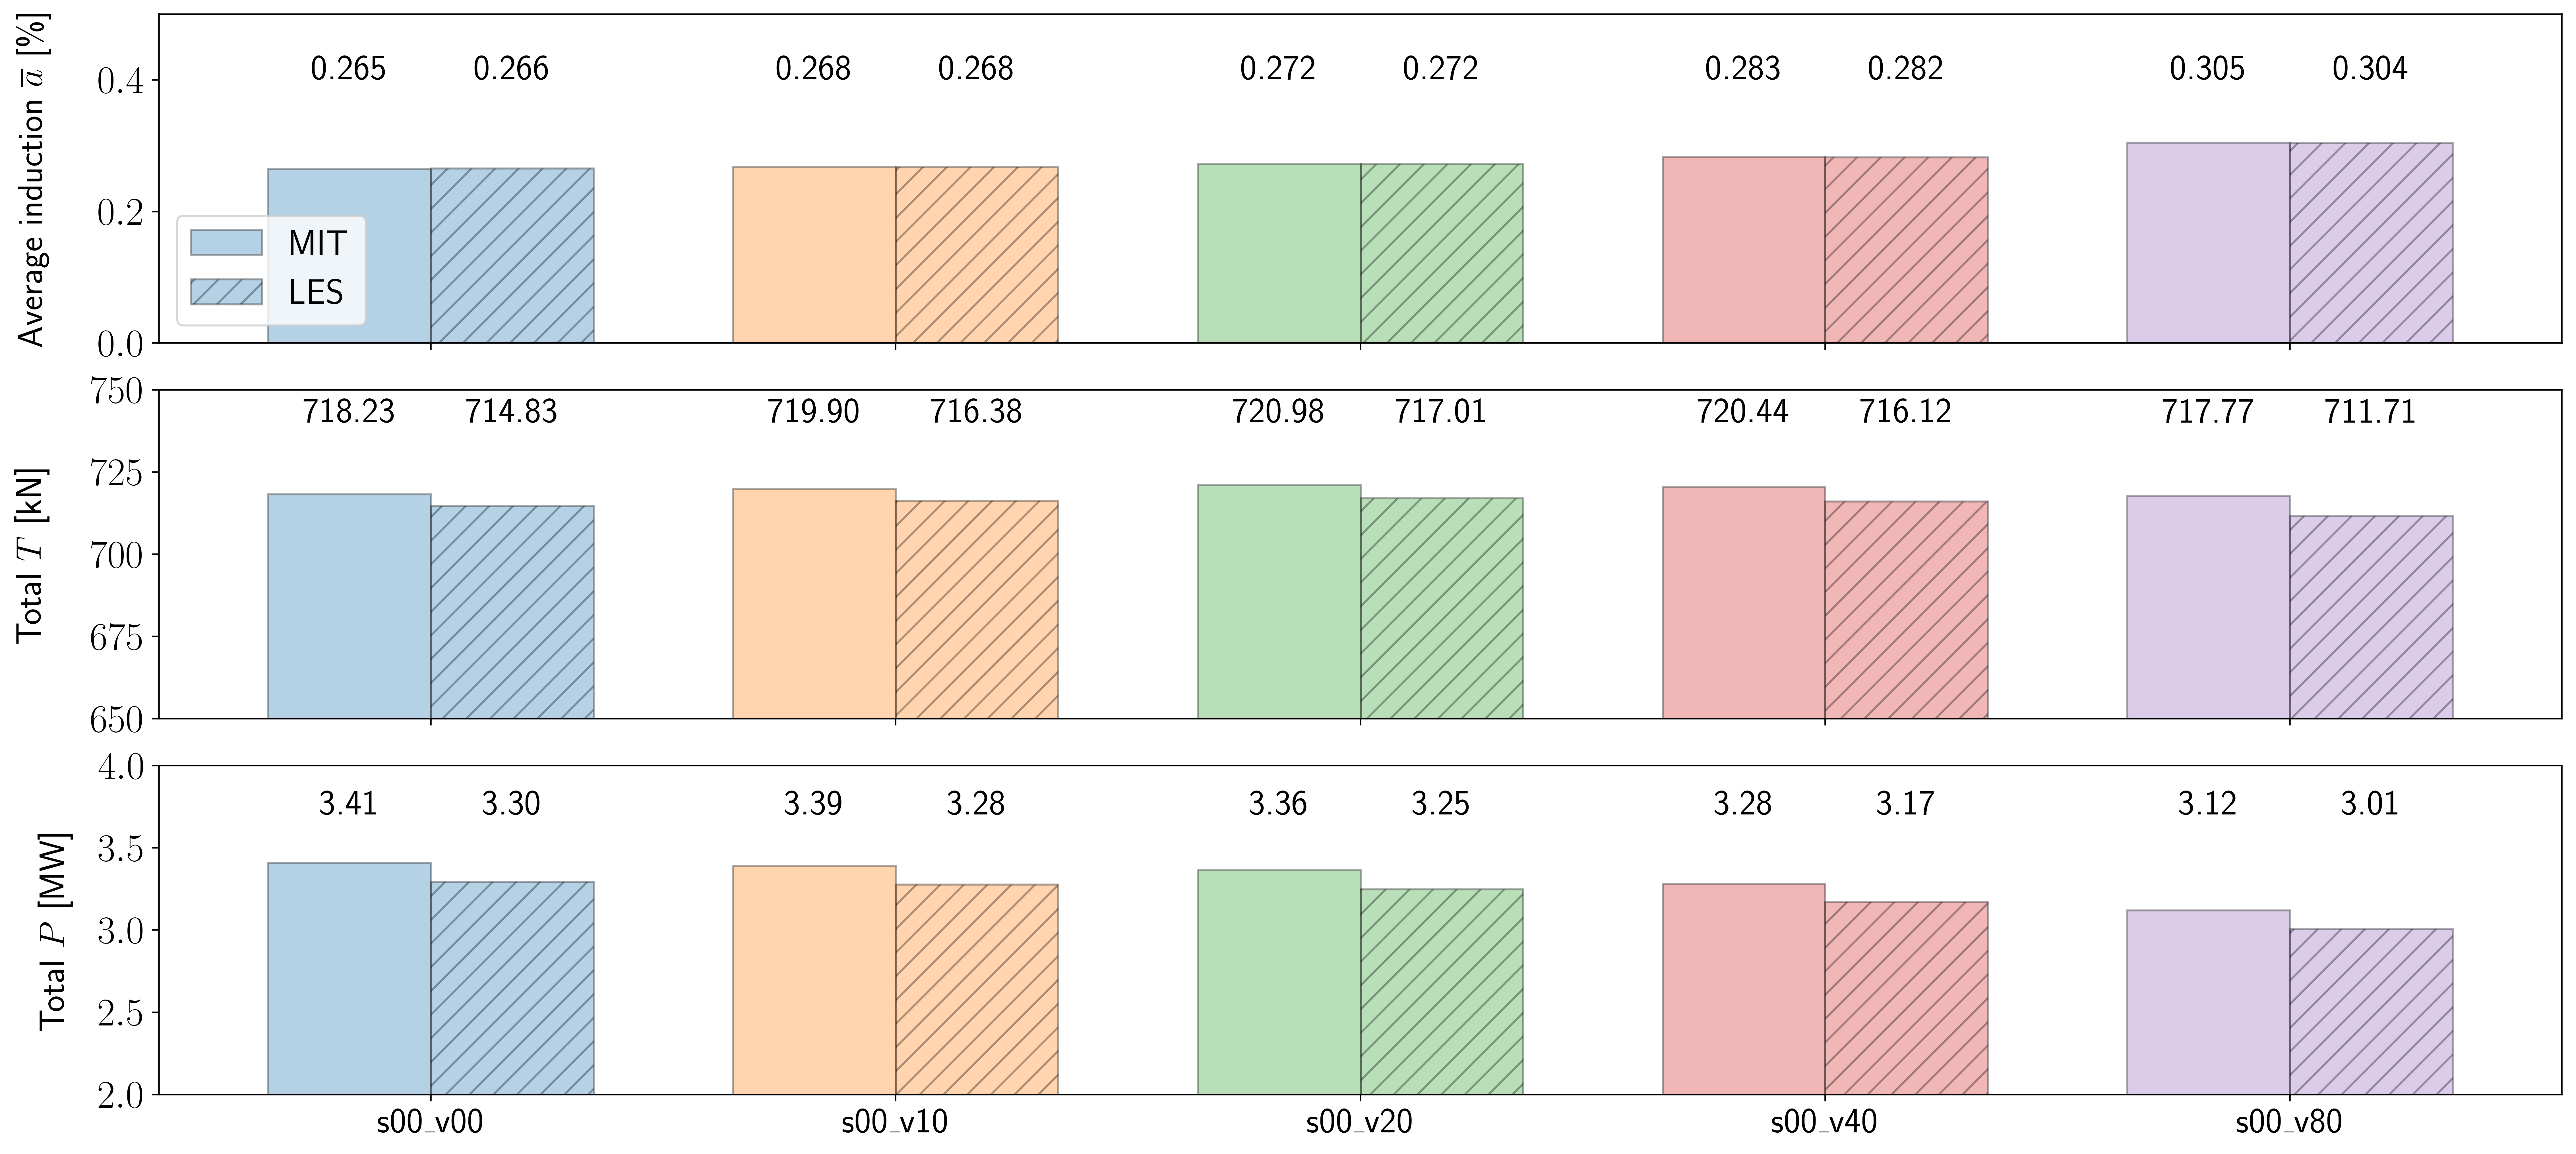

In [35]:
# Dimensional
casenames = [r's00_v00', r's00_v10', r's00_v20', r's00_v40', r's00_v80']

width = 0.35
alpha = 1/3
fontsize = 18

ind = np.arange(len(casenames))

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(casenames)):
    # --- Induction

    ax[0].bar(ind[count] - width/2, mit_ind[count], width,
              color=colors[count], edgecolor='black', alpha=alpha, label='MIT' if count == 0 else "")
    
    ax[0].bar(ind[count] + width/2, wrf_ind_ss[count], width,
              color=colors[count], edgecolor='black', alpha=alpha, hatch='//', label='LES' if count == 0 else "")
    
    ax[0].text(ind[count] - width/2, 0.4,
               f'{mit_ind[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].text(ind[count] + width/2, 0.4,
               f'{wrf_ind_ss[count]:0.3f}%', ha='center', fontsize=fontsize)
    
    ax[0].set_ylabel(r'Average induction $\overline{a}$ [\%]', fontsize=fontsize, labelpad=24)
    ax[0].set_ylim([0, 0.5])

    # --- Thrust

    ax[1].bar(ind[count] - width/2, mit_thr[count], width,
              color=colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_thr_ss[count]/1e3, width,
              color=colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[1].text(ind[count] - width/2, 740,
               f'{mit_thr[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].text(ind[count] + width/2, 740,
               f'{wrf_thr_ss[count]/1e3:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize, labelpad=21)
    ax[1].set_ylim([650, 750])

    # --- Power
    ax[2].bar(ind[count] - width/2, mit_pow[count], width,
              color=colors[count], edgecolor='black', alpha=alpha)
    
    ax[2].bar(ind[count] + width/2, wrf_pow_ss[count]/1e6, width,
              color=colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    ax[2].text(ind[count] - width/2, 3.7,
               f'{mit_pow[count]:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].text(ind[count] + width/2, 3.7,
               f'{wrf_pow_ss[count]/1e6:0.2f}%', ha='center', fontsize=fontsize)
    
    ax[2].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize, labelpad=13)
    ax[2].set_ylim([2, 4])

# Final formatting
ax[2].set_xticks(ind)
ax[2].set_xticklabels(casenames, fontsize=fontsize)
ax[2].tick_params(axis='x', rotation=0)

# Add legend for MIT vs. WRF
ax[0].legend(fontsize=fontsize, loc='lower left')

plt.show()


Text(0.5, 0, '$a$ [-]')

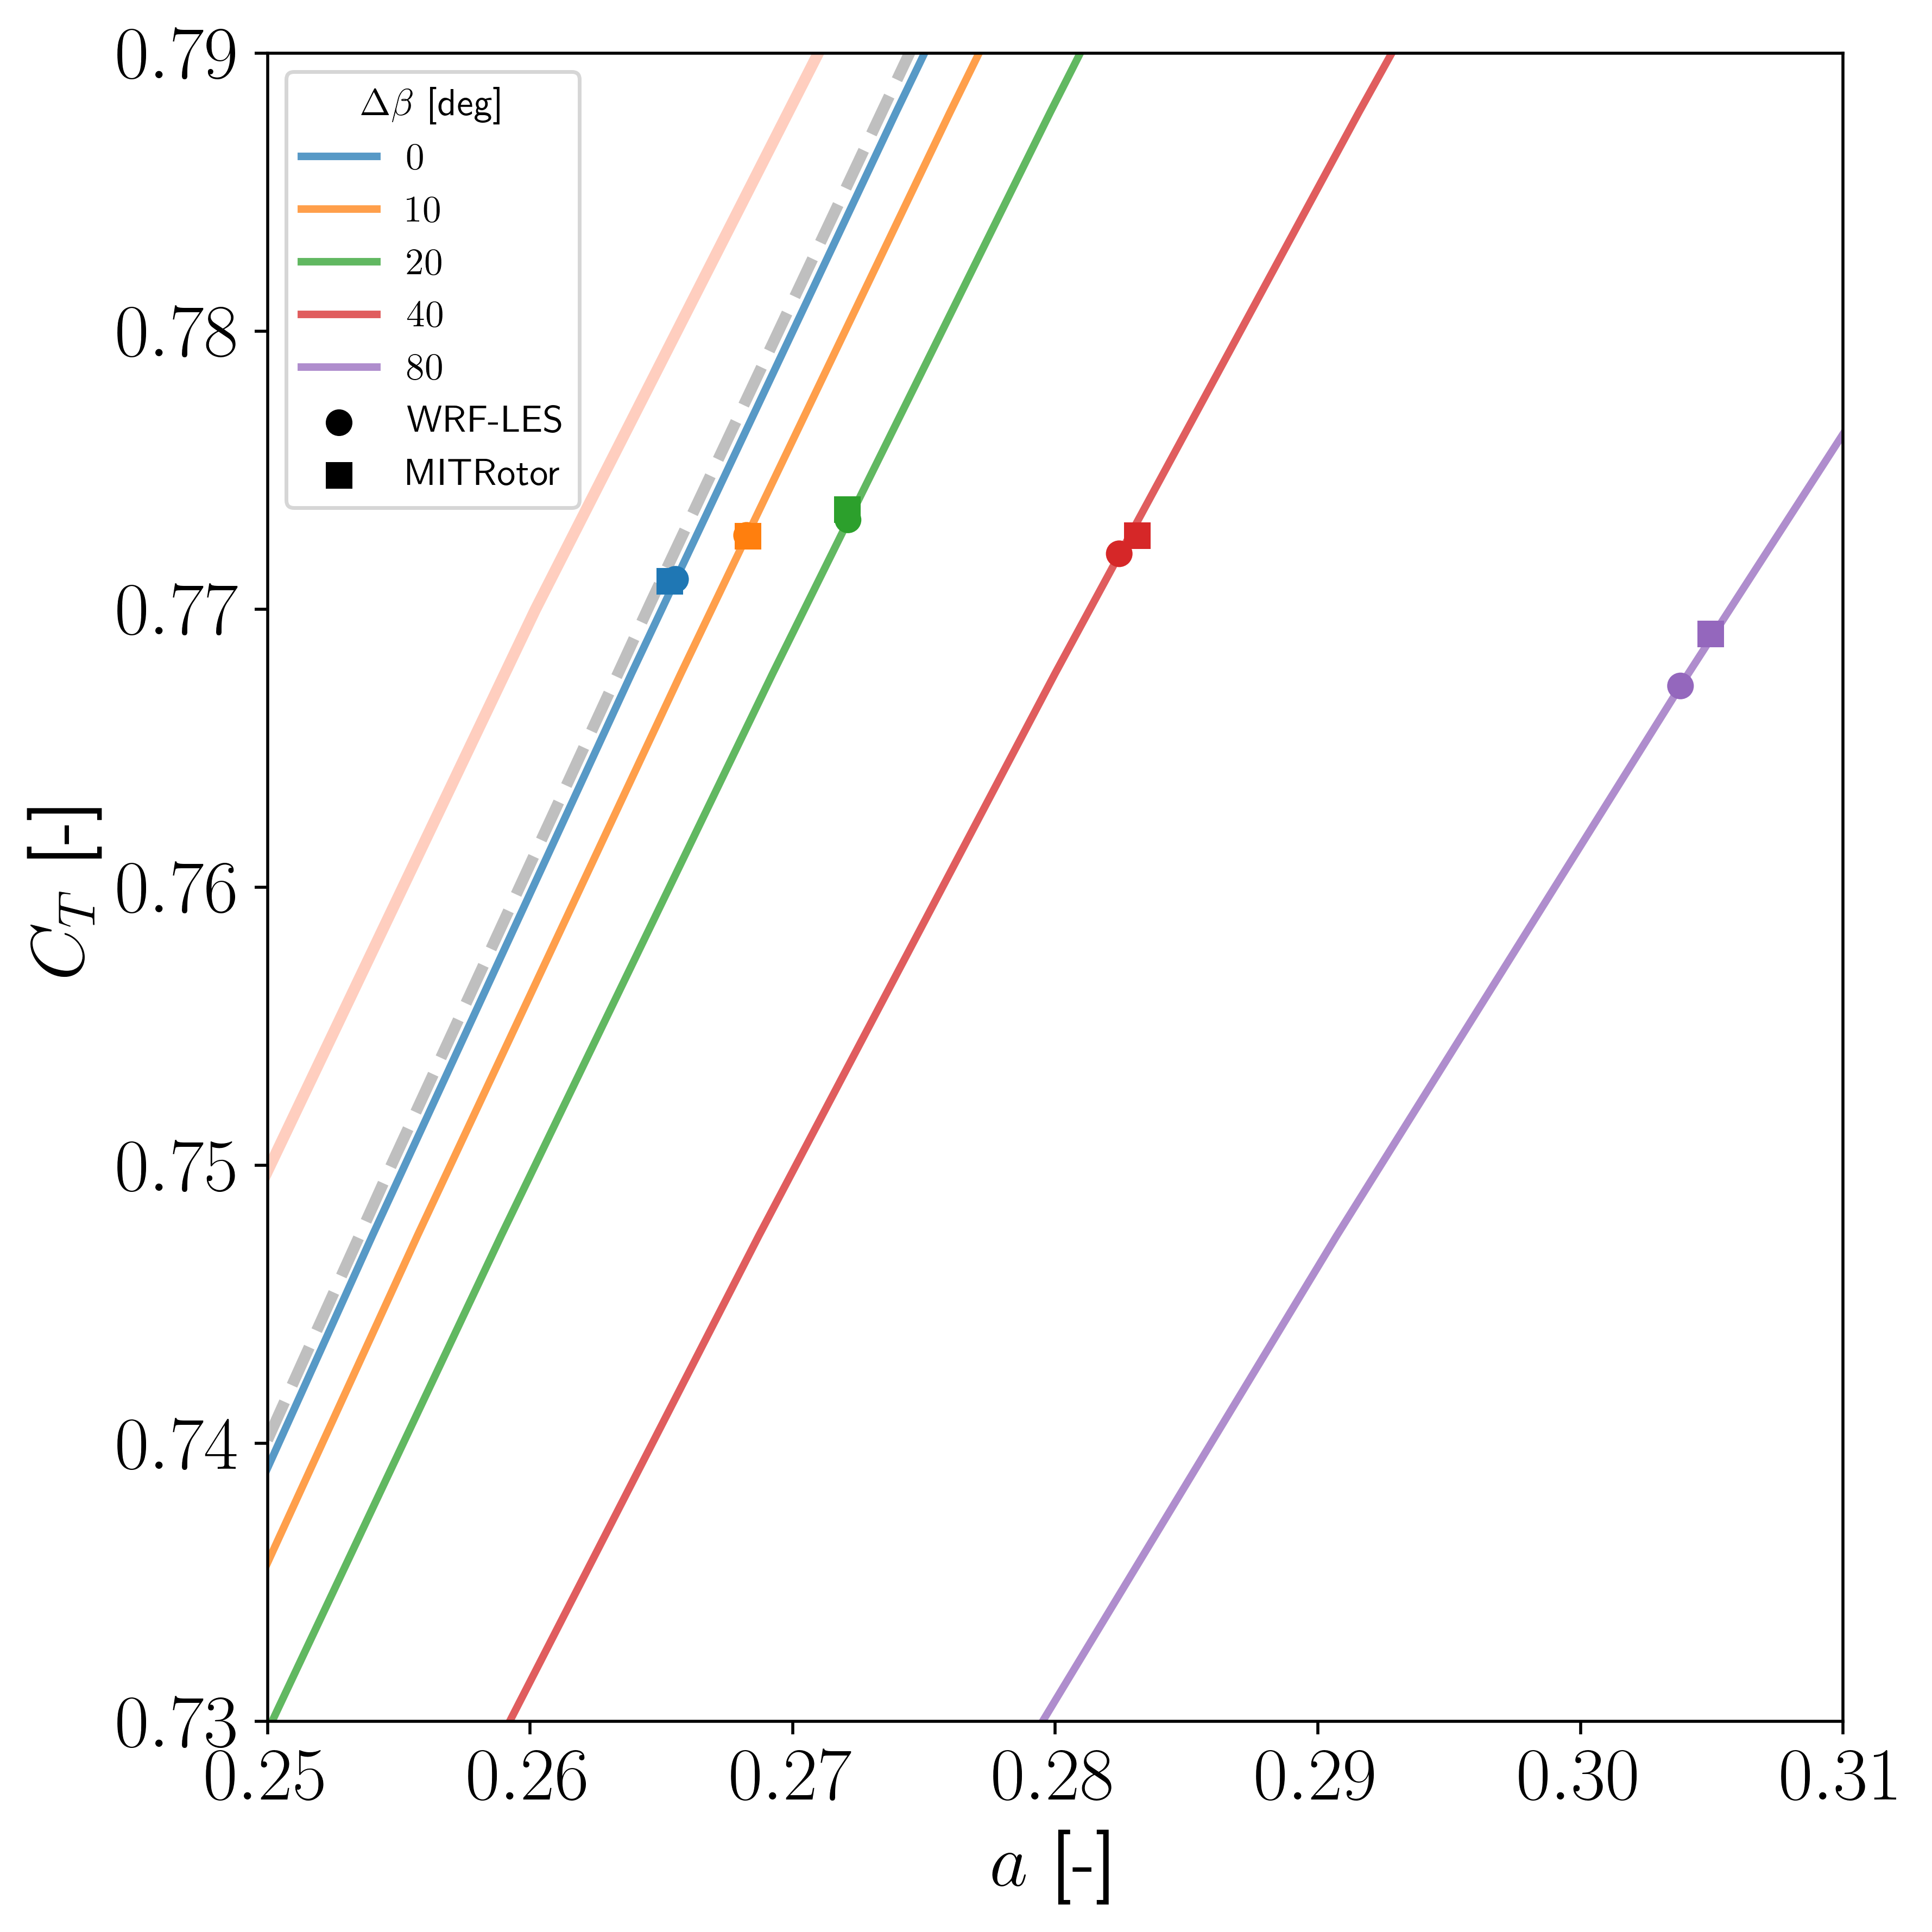

In [175]:
colors = sns.color_palette("tab10", 5)
colors = colors + colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)
mesh = ax.scatter(mit_ind[1], mit_cot[1], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[2], mit_cot[2], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[3], mit_cot[3], s=50, marker='s', edgecolor='none',color=colors[3],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[3],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[4],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

ax.set_xlim([0.25,0.31])
ax.set_ylim([0.73,0.79])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

In [ ]:
colors = sns.color_palette("tab10", 5)
colors = colors + colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$80$')

mesh = ax.scatter(mit_ind[0], mit_cot[0], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)
mesh = ax.scatter(mit_ind[1], mit_cot[1], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
mesh = ax.scatter(mit_ind[2], mit_cot[2], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
mesh = ax.scatter(mit_ind[3], mit_cot[3], s=50, marker='s', edgecolor='none',color=colors[3],zorder=3)
mesh = ax.scatter(mit_ind[4], mit_cot[4], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[3],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[4],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$\Delta \\beta$ [deg]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.5])

ax.set_xlim([0.25,0.31])
ax.set_ylim([0.73,0.79])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

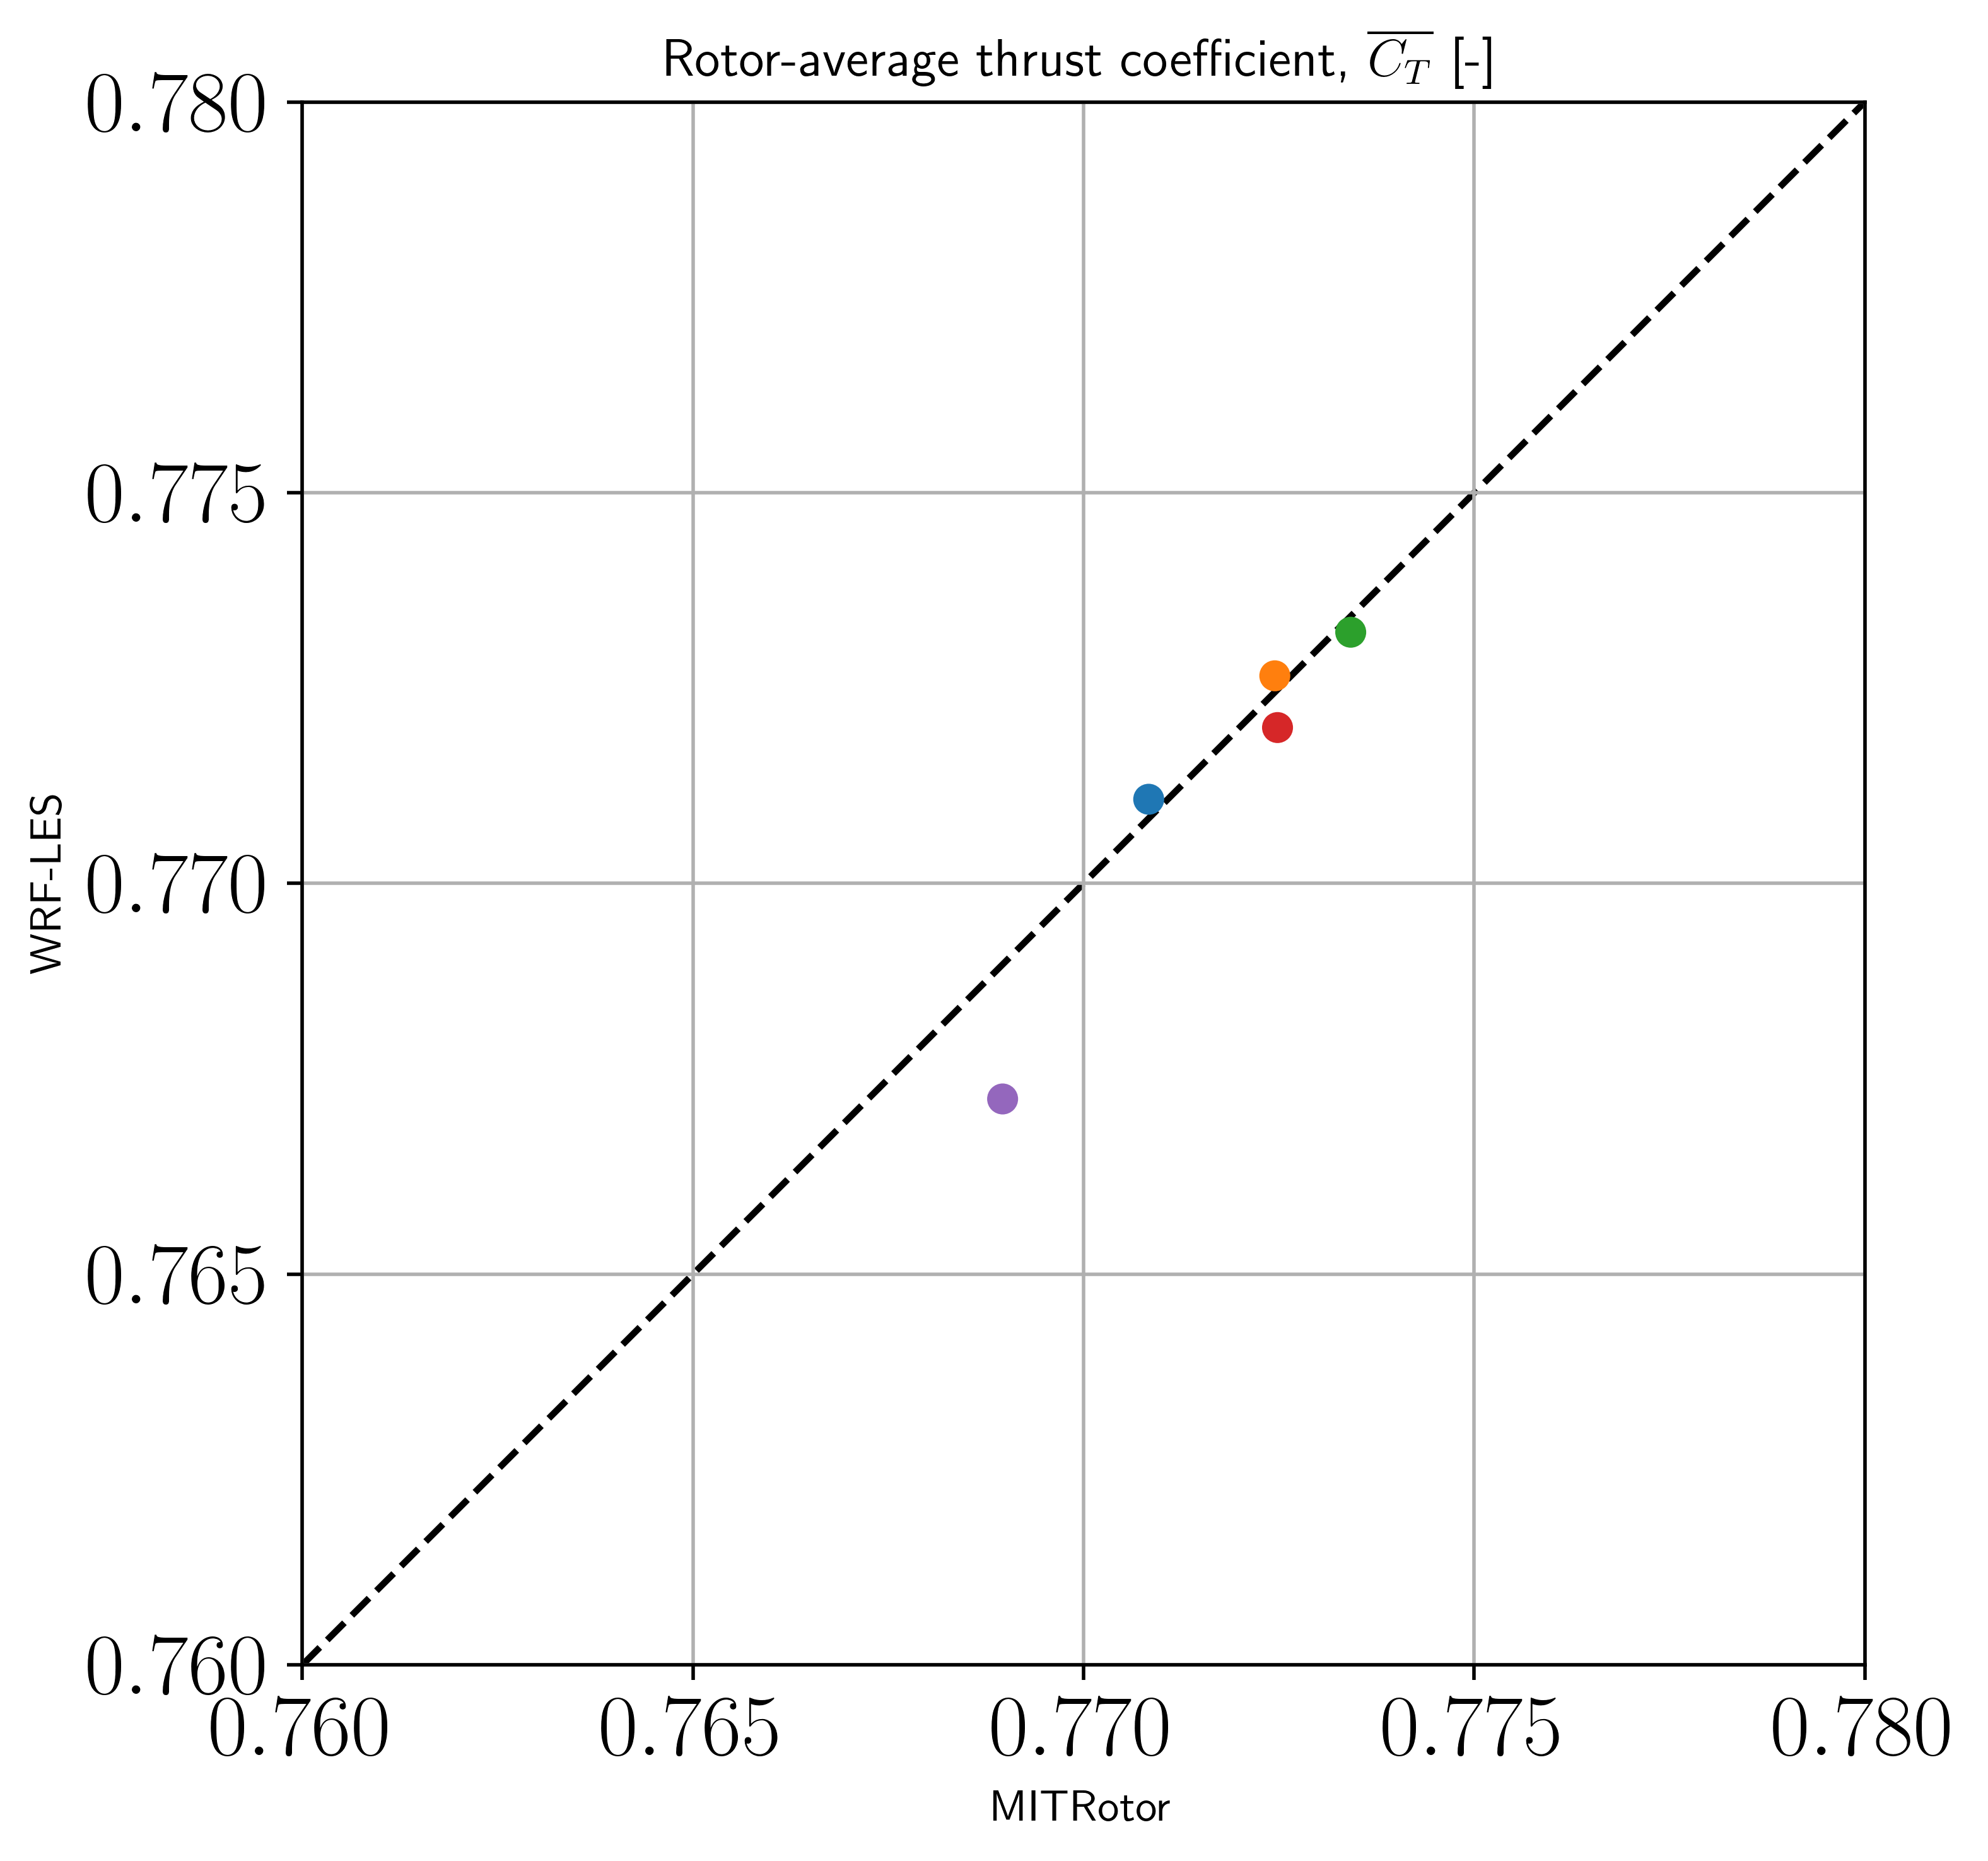

In [76]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_cot)):
    ax.scatter(mit_cot[i], wrf_cot[ind_ubar[i]], s=50, edgecolor='none', color=colors[i], zorder = i+2)

ax.plot([0,3],[0,3],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.76,0.78])
ax.set_ylim([0.76,0.78])
ax.set_aspect('equal')

plt.title(r"Rotor-average thrust coefficient, $\overline{C_T}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

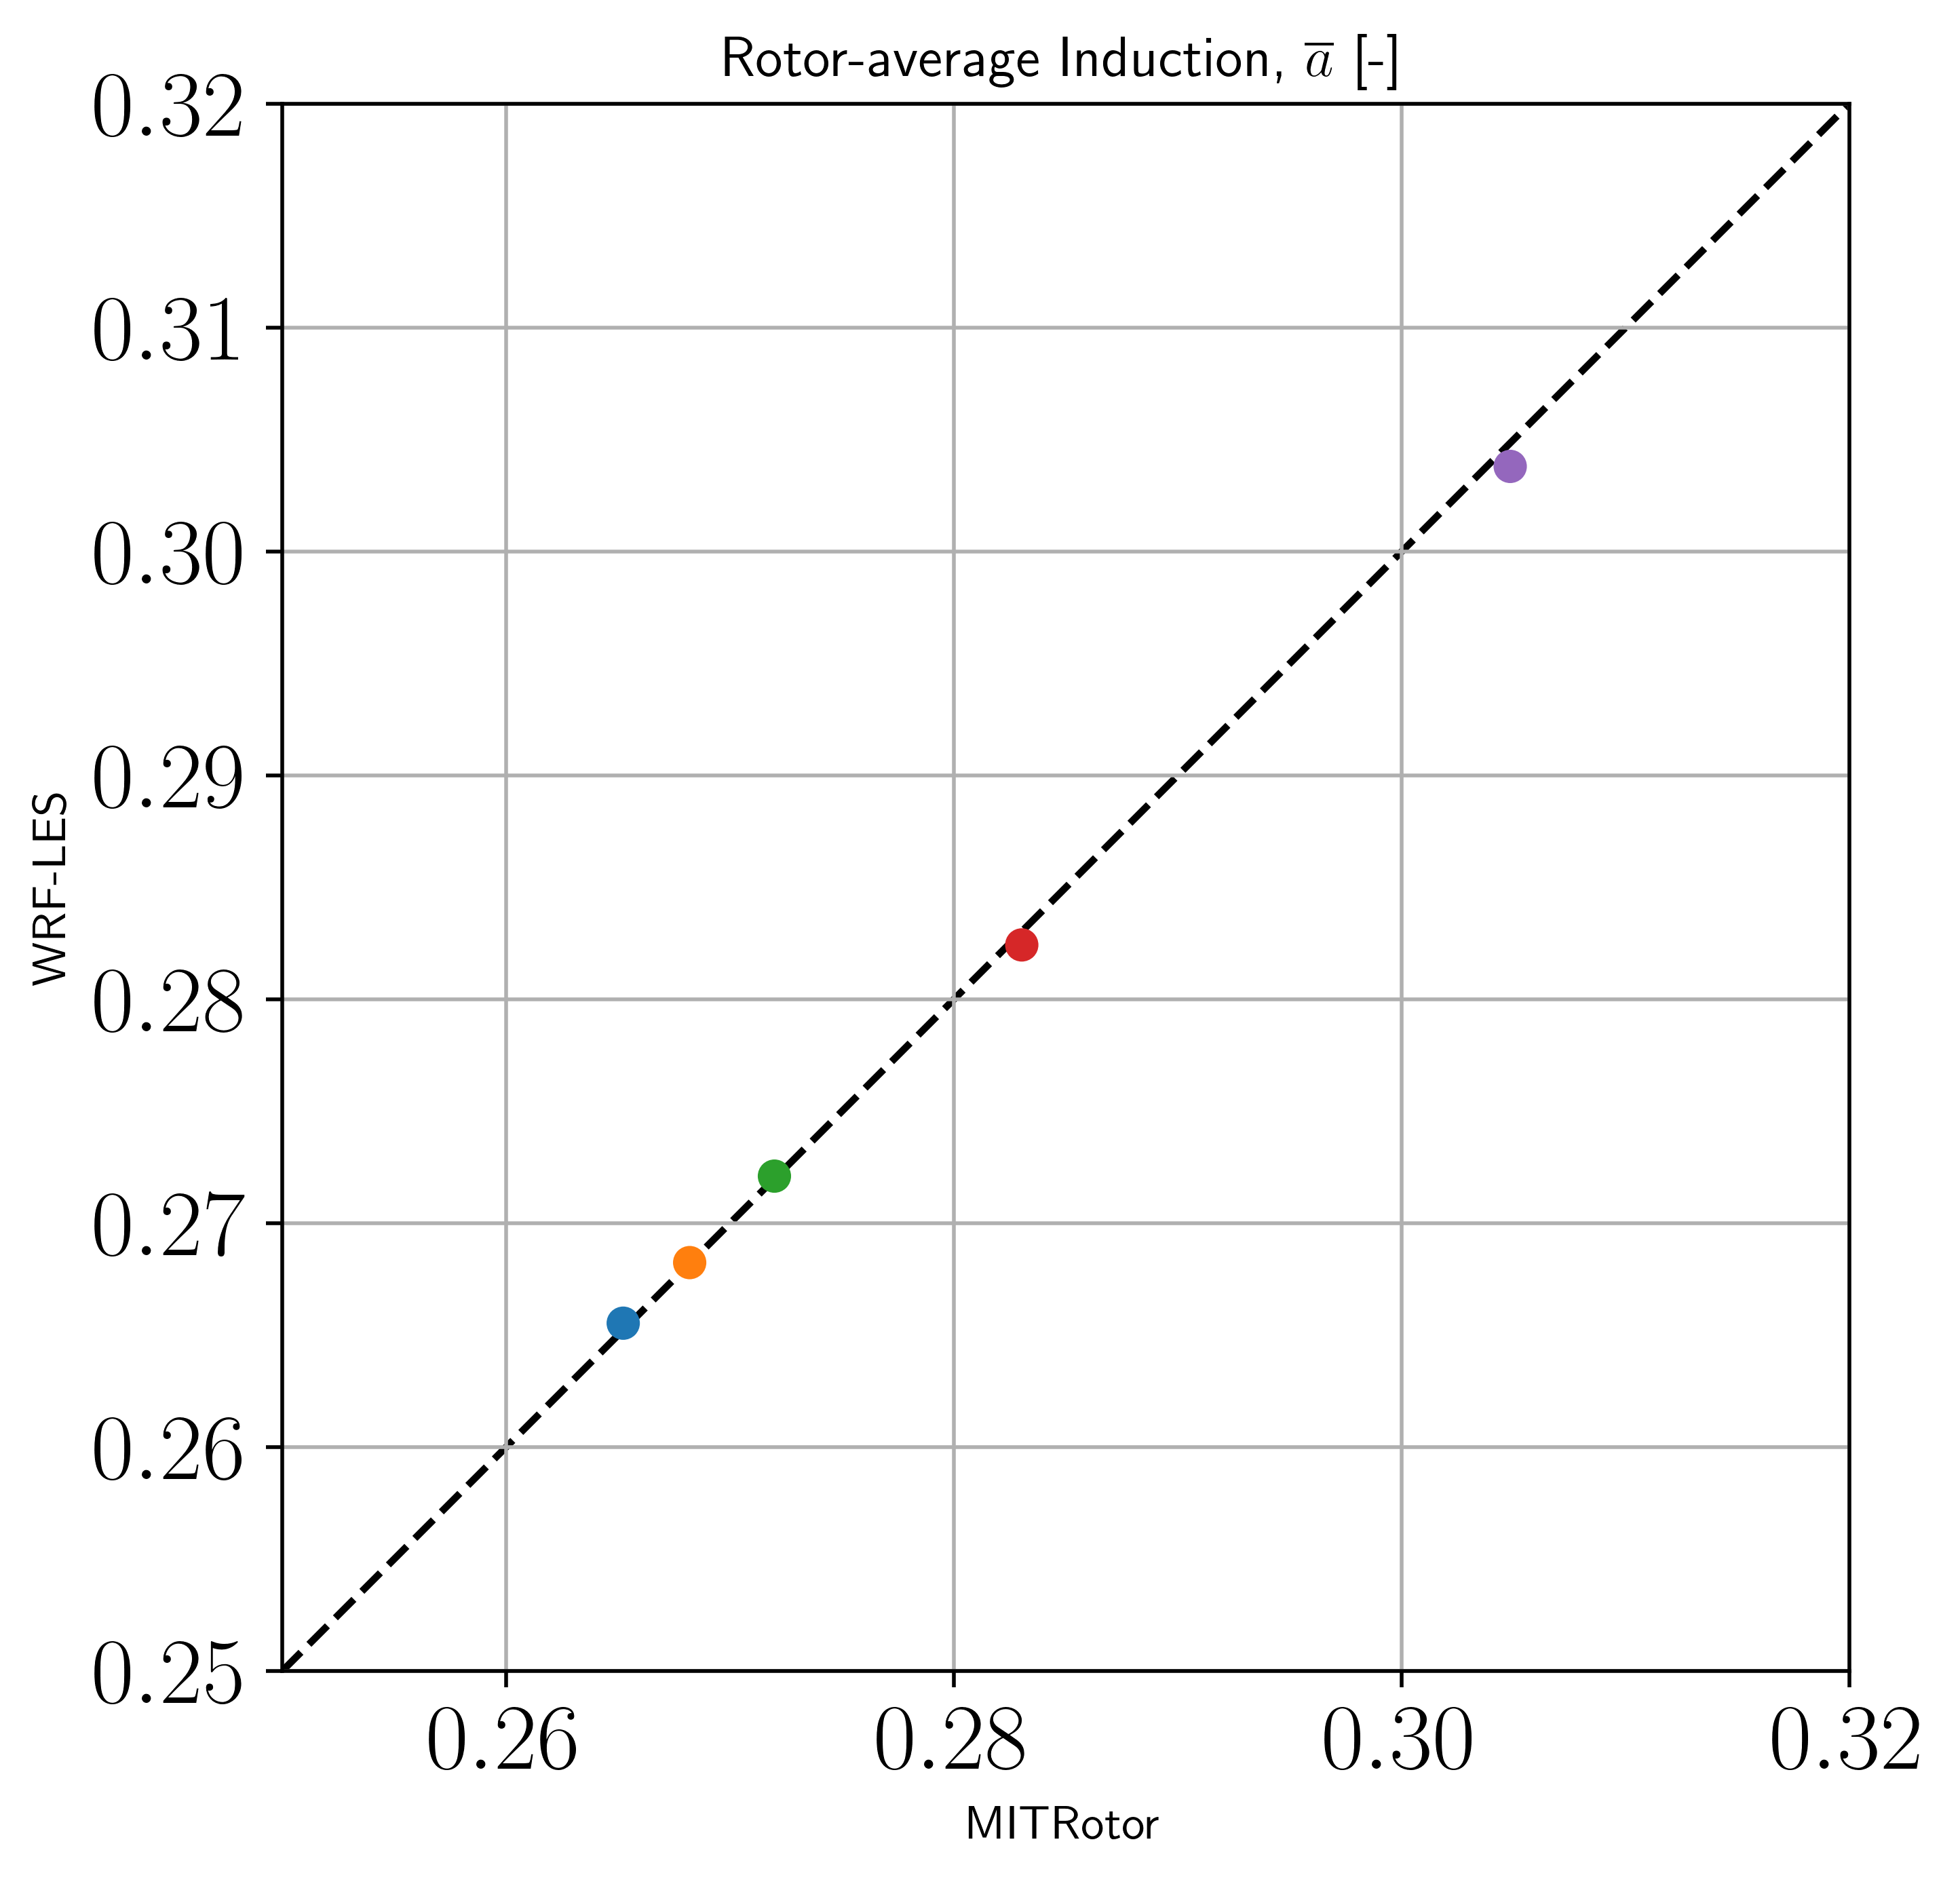

In [77]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_ind)):
    ax.scatter(mit_ind[i], wrf_ind[ind_ubar[i]], s=50, edgecolor='none', color=colors[i], zorder=i+2)

ax.plot([0,1],[0,1],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.25,0.32])
ax.set_ylim([0.25,0.32])
ax.set_aspect('equal')

plt.title(r"Rotor-average Induction, $\overline{a}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
# plt.tight_layout()
plt.show()

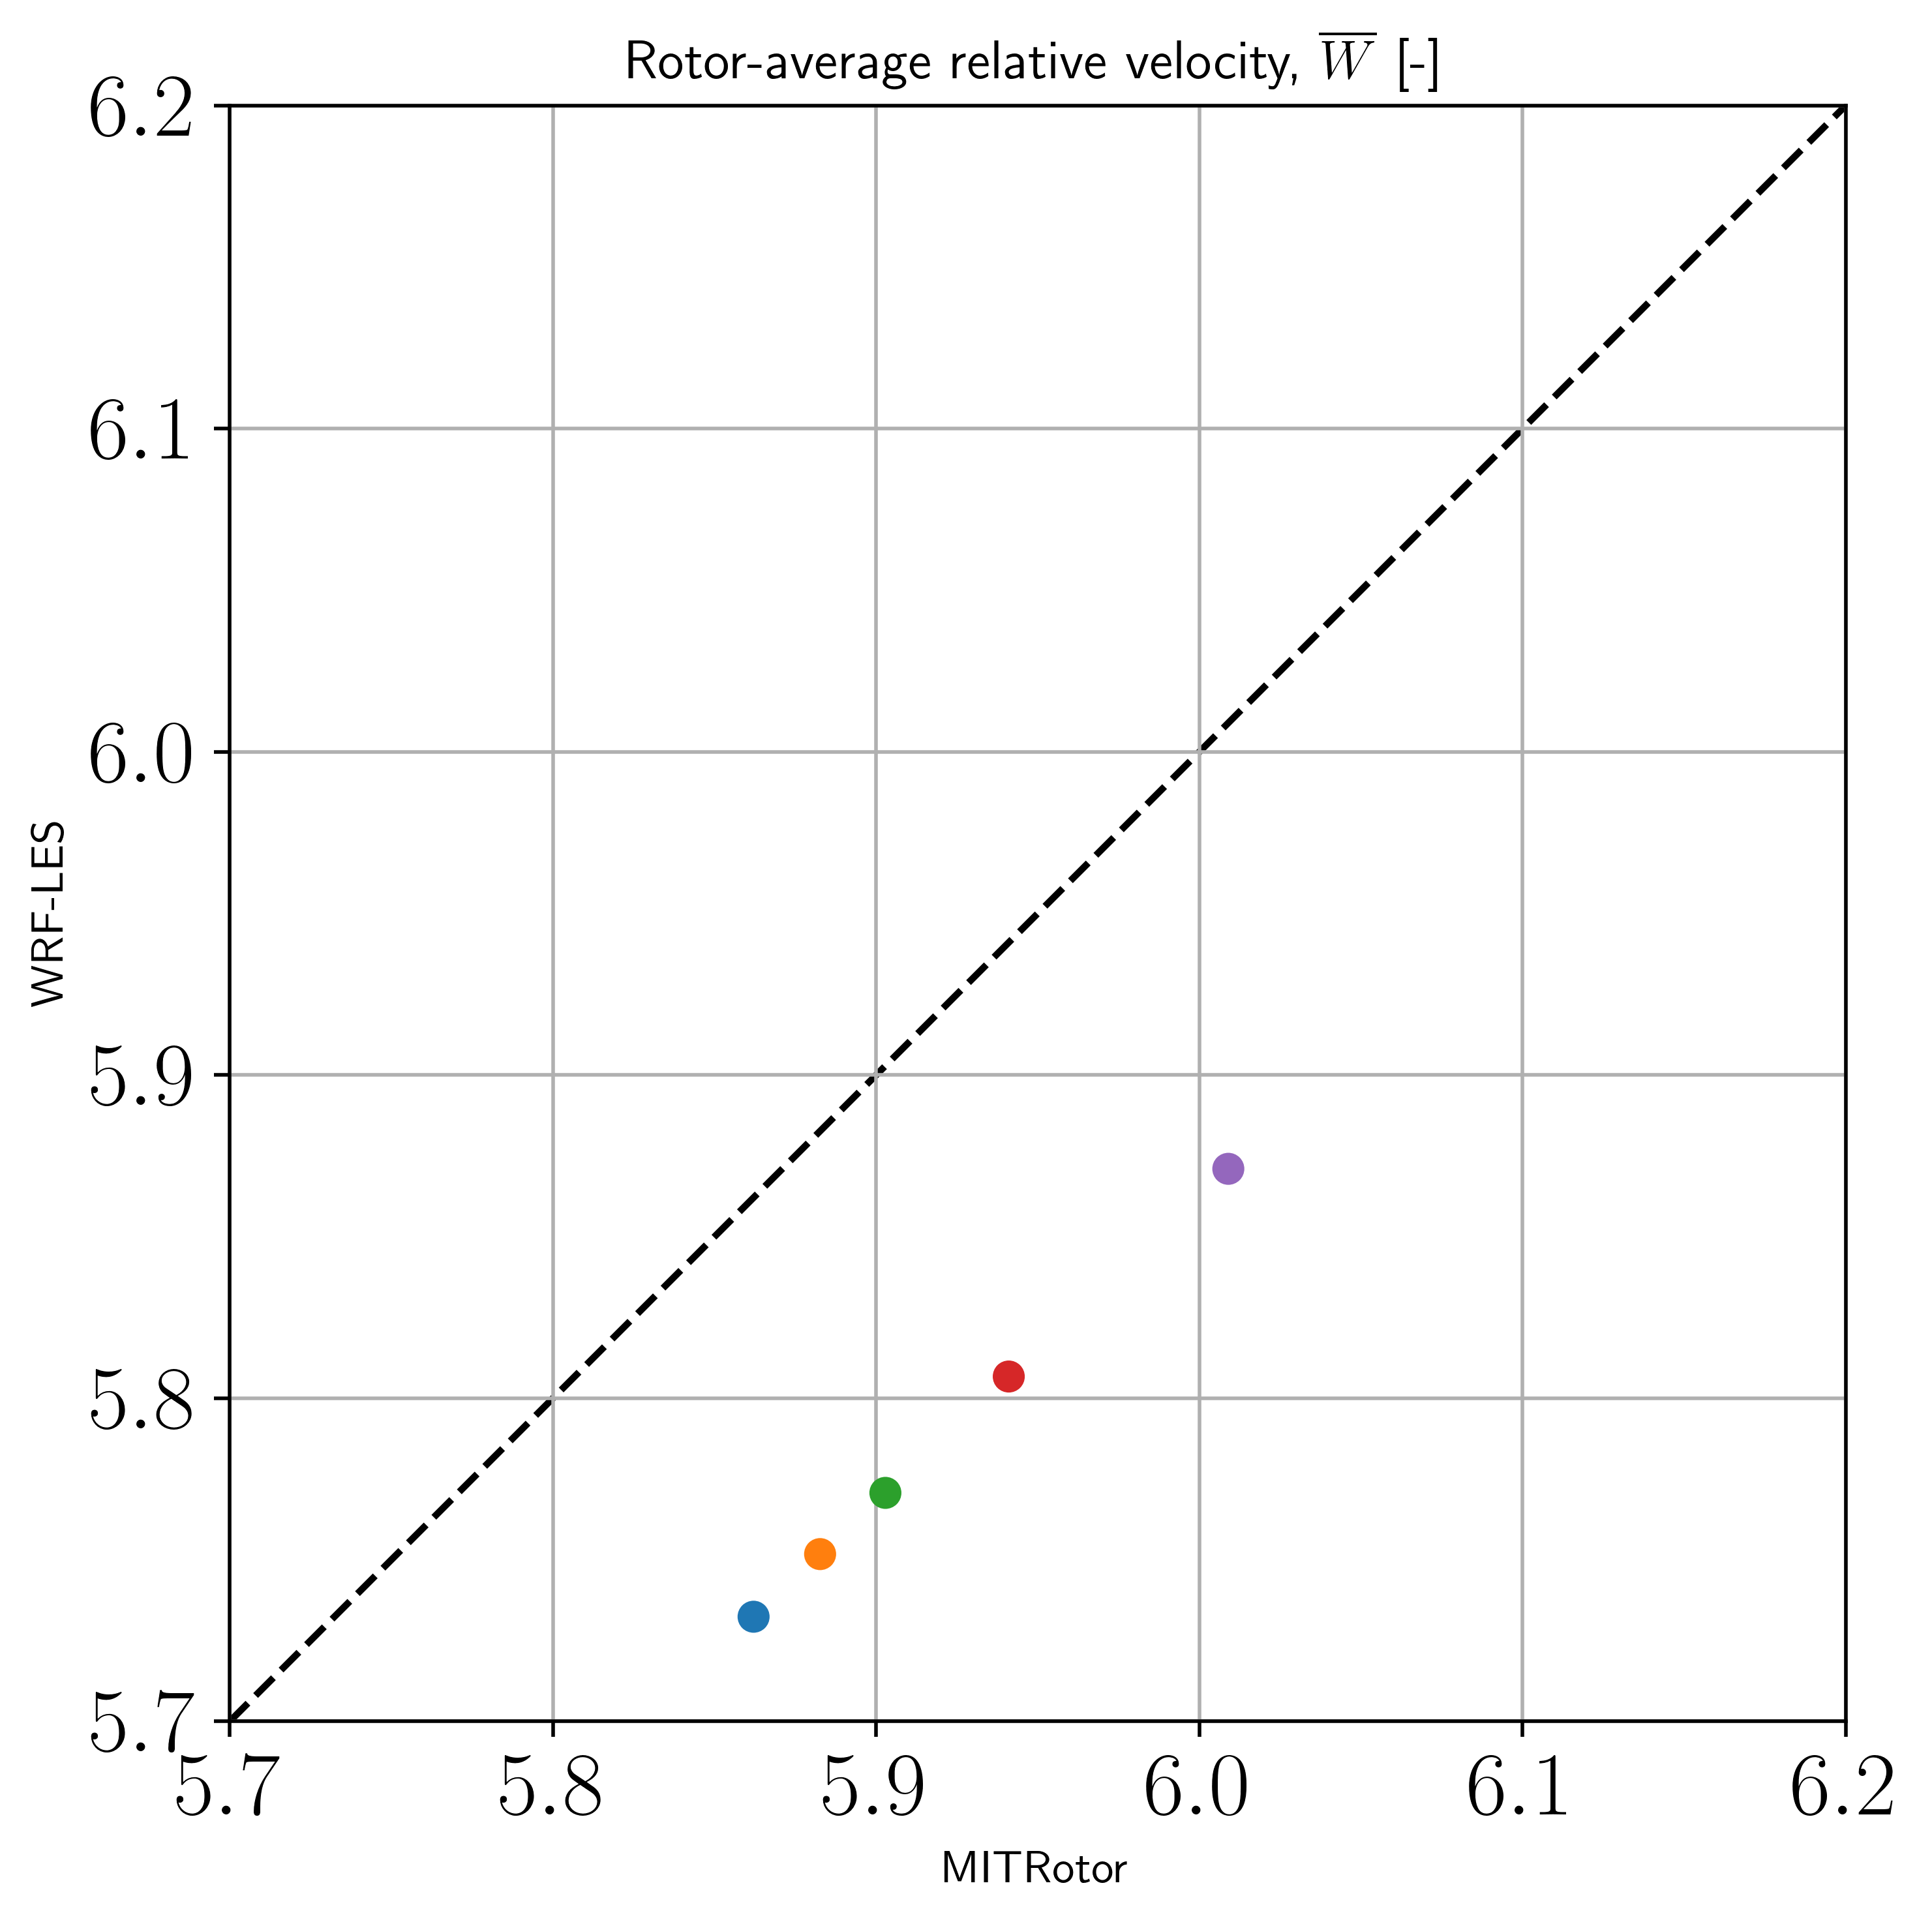

In [78]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_w)):
    ax.scatter(mit_w[i], wrf_rel[ind_ubar[i]], s=50, edgecolor='none', color=colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.7,6.2])
ax.set_ylim([5.7,6.2])
ax.set_aspect('equal')

plt.title(r"Rotor-average relative velocity, $\overline{W}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

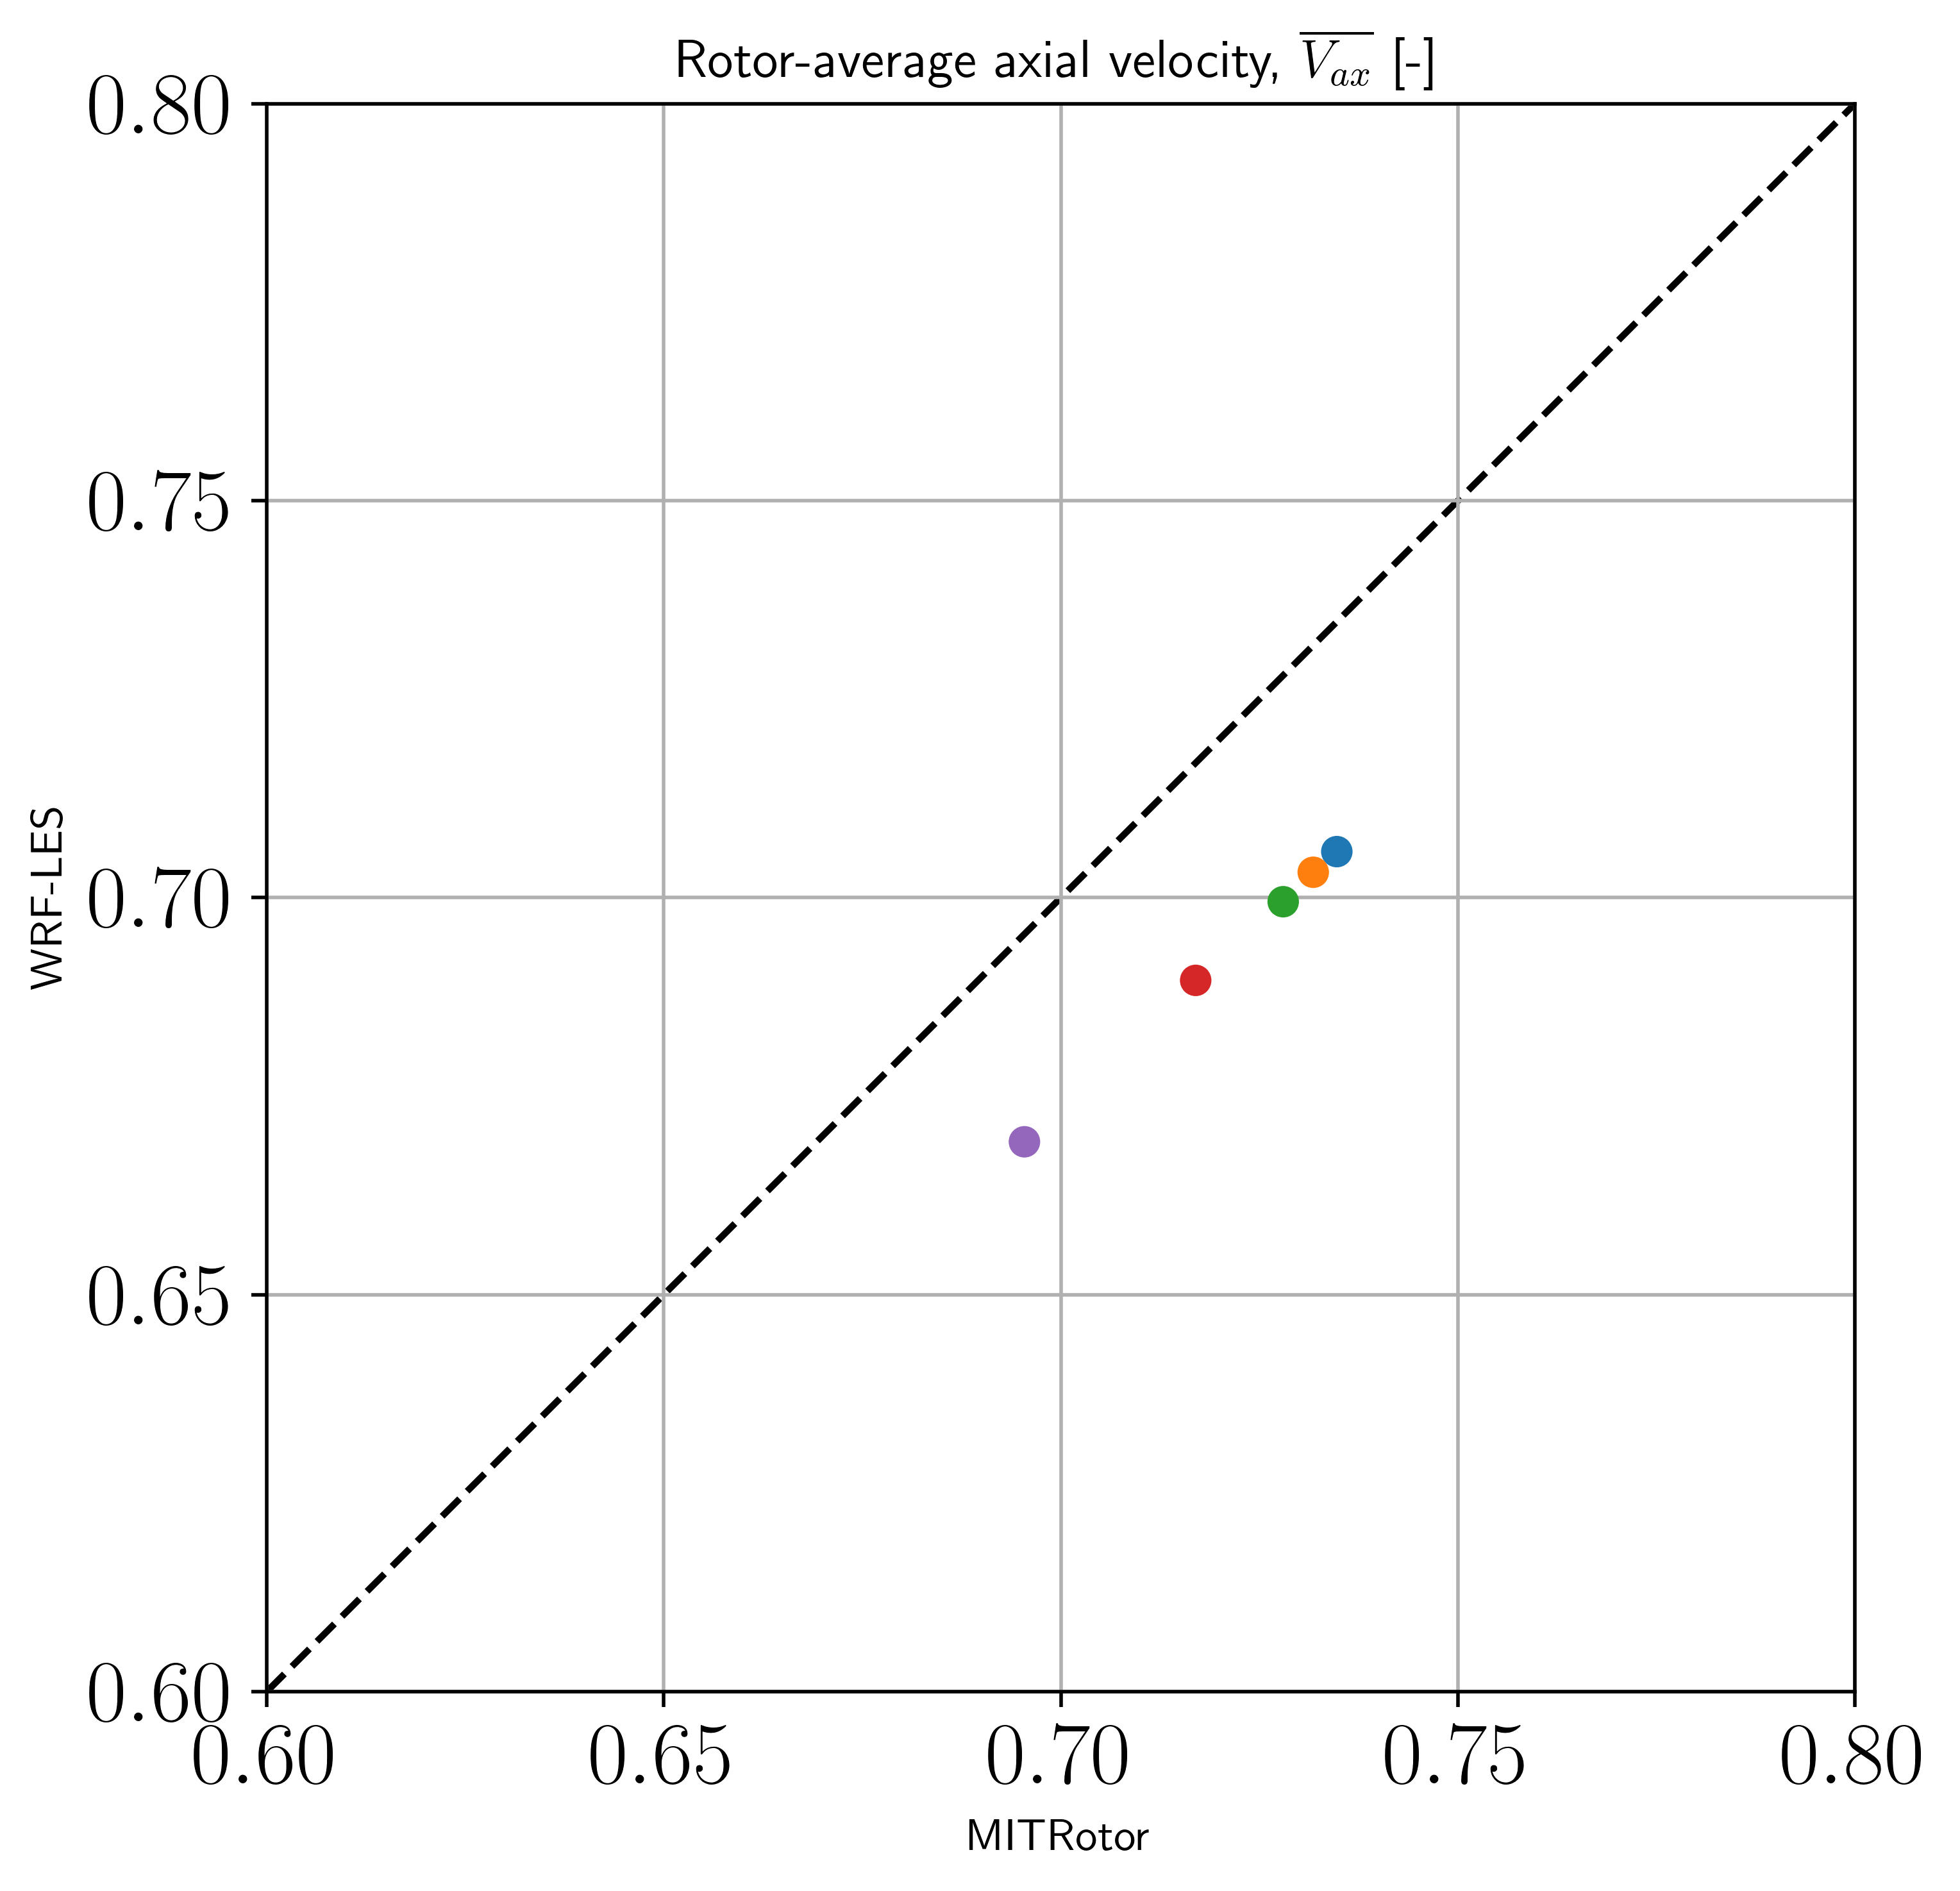

In [ ]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vax)):
    ax.scatter(mit_vax[i], wrf_vax[ind_ubar[i]], s=50, edgecolor='none', color=colors[i], zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.6,0.8])
ax.set_ylim([0.6,0.8])
ax.set_aspect('equal')

plt.title(r"Rotor-average axial velocity, $\overline{V_{ax}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

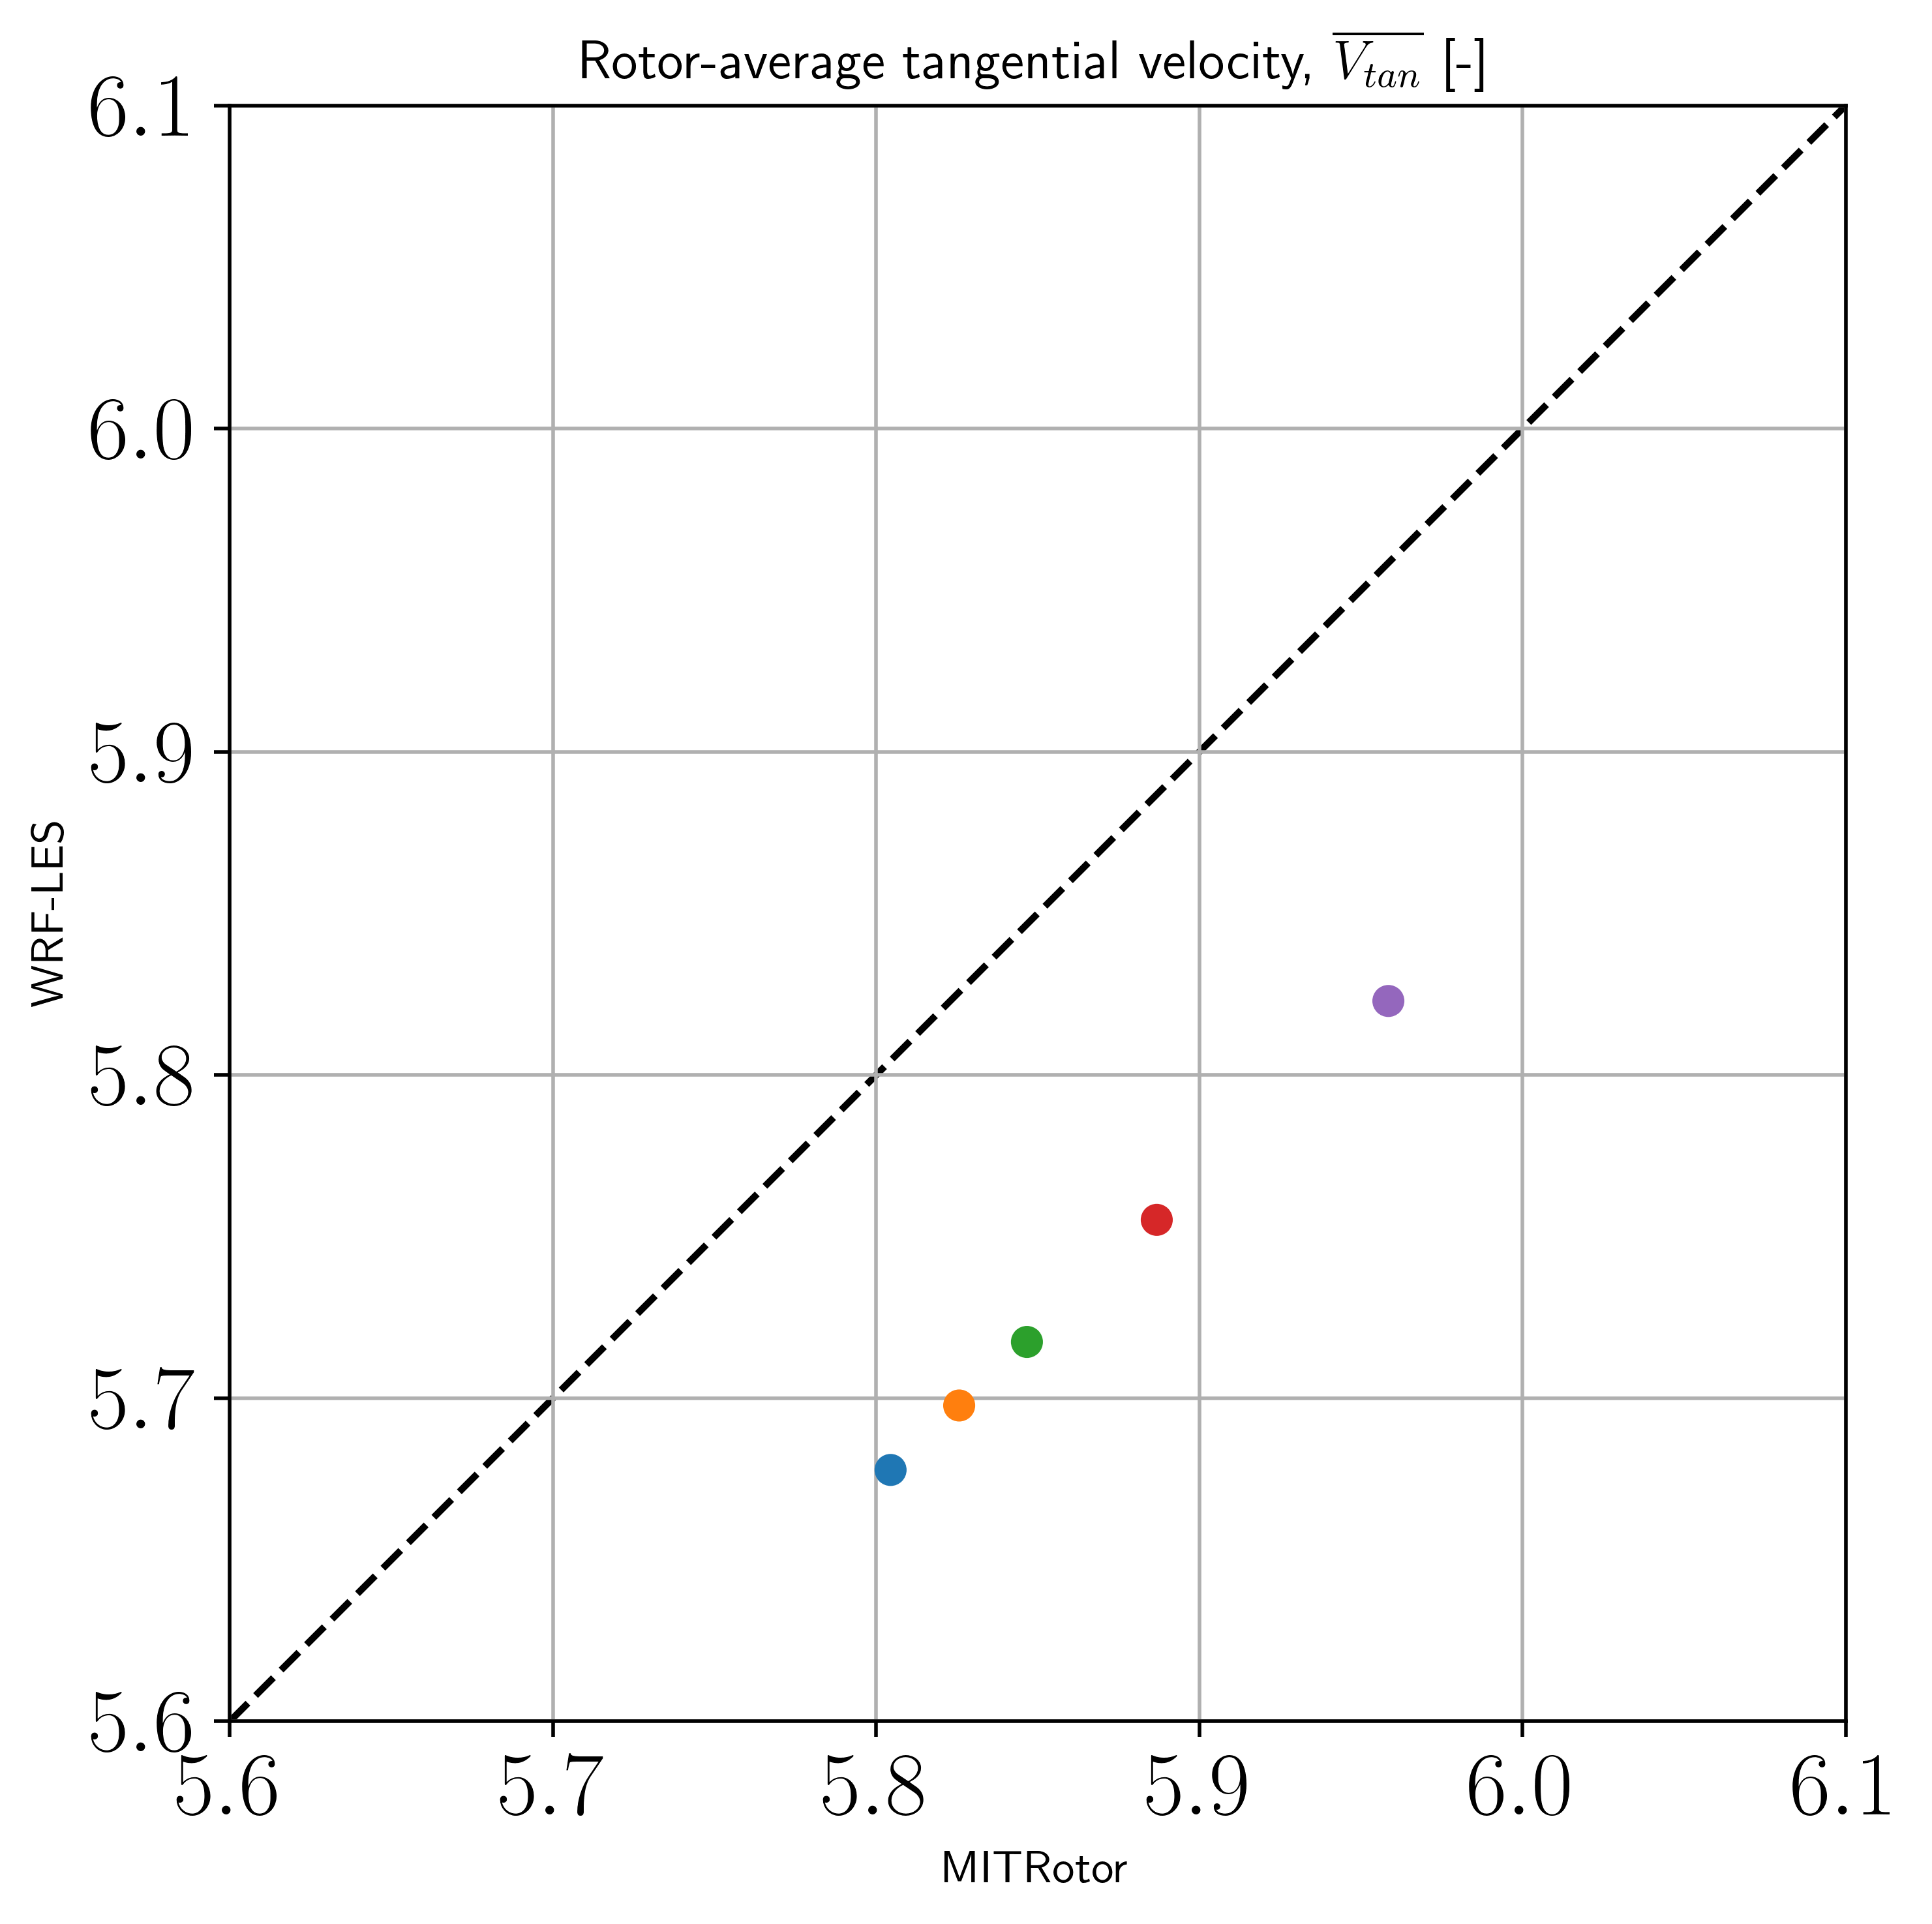

In [87]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vtn)):
    ax.scatter(mit_vtn[i], wrf_vtn[ind_ubar[i]], s=50, edgecolor='none', color=colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.6,6.1])
ax.set_ylim([5.6,6.1])
ax.set_aspect('equal')

plt.title(r"Rotor-average tangential velocity, $\overline{V_{tan}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()